## **Q4: Which municipalities and school clusters have the largest numbers and proportions of learners with disabilities enrolled in schools without a SPED Center or ILRC within a 3-kilometer radius? For each existing center or ILRC, what are the numbers and disability profiles of learners in the host school and in surrounding schools within the same radius?**

**Datasets used in this notebook**

| File | Role |
|---|---|
| `sned_facility_roster.csv` | Per-school ILRC / SPED Center / SNED-implementing tags, used to build municipality- and division-level facility counts. |
| `sned_access_public_pairs.csv` / `sned_access_pubpriv_pairs.csv` | Facility ↔ school 3km distance pairs (host + every satellite within range), for the public-only and public + private school populations respectively (`pub_pairs` / `pp_pairs`). |
| `sned_access_public_summary.csv` / `sned_access_pubpriv_summary.csv` | Per-school access summary — nearest facility, count within 3km, access flag (`pub_summary` / `pp_summary`). |
| `sned_access_public_lgu_counts.csv` / `sned_access_pubpriv_lgu_counts.csv` | Municipality-level access roll-up, incl. the boundary "desert" flag (`lgu_pub` / `lgu_pp`). |
| `sned_database_tidy_long.parquet` | SNED learner counts by school, disability category, diagnosis type, grade, and sex. Queried through DuckDB throughout so the raw table is never loaded into pandas. |
| `consolidated_geodata_matched.gpkg` | Barangay-level boundary polygons for every choropleth and network map. (Caveat: NCR and BARMM areas are not cleanly organized here, potentially leading to some discrepancies) |
| `public_school_coordinates.parquet` / `private_school_coordinates.parquet` | School-level lat/lon, used to plot the facility-cluster network maps. |

### **A. Preliminaries**

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from pathlib import Path
import geopandas as gpd
import duckdb
import networkx as nx
from scipy.stats import chi2_contingency, wilcoxon
pd.set_option('display.max_columns', None)

REGION_SHORT = {
    'Region I (Ilocos Region)':       'Ilocos Region',
    'Region II (Cagayan Valley)':     'Cagayan Valley',
    'Cordillera Administrative Region (CAR)': 'CAR',
    'Region III (Central Luzon)':     'Central Luzon',
    'National Capital Region (NCR)':  'NCR',
    'Region IV-A (CALABARZON)':       'CALABARZON',
    'MIMAROPA Region':                'MIMAROPA',
    'Region V (Bicol Region)':        'Bicol Region',
    'Region VI (Western Visayas)':    'Western Visayas',
    'Negros Island Region (NIR)':     'NIR',
    'Region VII (Central Visayas)':   'Central Visayas',
    'Region VIII (Eastern Visayas)':  'Eastern Visayas',
    'Region IX (Zamboanga Peninsula)':'Zamboanga Peninsula',
    'Region X (Northern Mindanao)':   'Northern Mindanao',
    'Region XI (Davao Region)':       'Davao Region',
    'Region XII (SOCCSKSARGEN)':      'SOCCSKSARGEN',
    'Region XIII (Caraga)':           'Caraga',
    'Bangsamoro Autonomous Region In Muslim Mindanao (BARMM)': 'BARMM',
}
REGION_ORDER = list(REGION_SHORT.values())

from pyfonts import set_default_font, load_google_font
regular = load_google_font("Inter")
bold    = load_google_font("Inter", weight="bold")
set_default_font(regular)

_ROOT = Path.cwd().parent
DATA  = _ROOT / "data"
EXTERNAL = DATA / "external"

roster   = pd.read_csv(DATA / "sned_facility_roster.csv")
pub_pairs   = pd.read_csv(DATA / "sned_access_public_pairs.csv")
pp_pairs    = pd.read_csv(DATA / "sned_access_pubpriv_pairs.csv")
pub_summary = pd.read_csv(DATA / "sned_access_public_summary.csv")
pp_summary  = pd.read_csv(DATA / "sned_access_pubpriv_summary.csv")
lgu_pub = pd.read_csv(DATA / "sned_access_public_lgu_counts.csv")
lgu_pp  = pd.read_csv(DATA / "sned_access_pubpriv_lgu_counts.csv")

lgu_pub = lgu_pub.rename(columns={"n_public_schools": "n_population_schools"})
lgu_pp  = lgu_pp.rename(columns={"n_public_schools": "n_population_schools"})

PARQUET_PATH = DATA / "sned_database_tidy_long.parquet"

def add_region_short(df, col="psgc_region_name"):
    out = df.copy()
    out["region_short"] = pd.Categorical(
        out[col].map(REGION_SHORT), categories=REGION_ORDER, ordered=True
    )
    return out

PASTEL = plt.get_cmap("Set2").colors
SCALE_CMAP = "PiYG_r"

In [2]:
con = duckdb.connect()
con.register("roster_df", roster)

unmatched_facilities = con.execute(f"""
    WITH parquet_ids AS (
        SELECT DISTINCT beis_school_id
        FROM read_parquet('{PARQUET_PATH.as_posix()}')
    )
    SELECT r.school_id, r.school_name, r.psgc_region_name, r.psgc_province_name,
           r.psgc_municity_name, r.is_ilrc, r.is_sned, r.is_sped_center, r.coord_status
    FROM roster_df r
    LEFT JOIN parquet_ids p ON r.school_id = p.beis_school_id
    WHERE p.beis_school_id IS NULL
    ORDER BY r.psgc_region_name, r.psgc_municity_name
""").df()

n_roster = len(roster)
n_unmatched = len(unmatched_facilities)
print(f"Facility-roster schools: {n_roster}")
print(f"Not found in SNED database (beis_school_id): {n_unmatched} "
      f"({n_unmatched / n_roster:.1%})")
unmatched_facilities



Facility-roster schools: 2629
Not found in SNED database (beis_school_id): 12 (0.5%)


,school_id,school_name,psgc_region_name,psgc_province_name,psgc_municity_name,is_ilrc,is_sned,is_sped_center,coord_status
0,136690,Makati ES,National Capital Region (NCR),City of Makati,City of Makati,False,True,False,valid
1,136710,Nemesio I. Yabut ES,National Capital Region (NCR),City of Makati,City of Makati,False,True,False,valid
2,107287,Calaca Central School,Region IV-A (CALABARZON),Batangas,City of Calaca,False,True,False,valid
3,108473,Dita Elementary School,Region IV-A (CALABARZON),Laguna,City of Santa Rosa,False,True,True,valid
4,109255,Kalumpang Elementary School,Region IV-A (CALABARZON),Quezon,City of Tayabas,False,True,True,valid
5,124618,Kalucap ES,Region IX (Zamboanga Peninsula),Zamboanga del Norte,Salug,False,True,False,valid
6,112134,Daet Elementary School,Region V (Bicol Region),Camarines Norte,Daet,True,False,True,valid
7,130453,Congan Elementary School,Region XII (SOCCSKSARGEN),Sarangani,Glan,False,True,False,valid
8,119412,Jubay Elementary School,NaN,NaN,NaN,False,True,False,valid
9,129443,A.S. Manjoorsa Elementary School,NaN,NaN,NaN,False,True,False,valid


### **B. SPED facility landscape**

In [3]:
total_public_schools   = int(lgu_pub["n_population_schools"].sum())   # national public-school universe
total_pubpriv_schools  = int(lgu_pp["n_population_schools"].sum())    # national public+private universe

roster["is_any_facility"] = roster[["is_ilrc", "is_sned", "is_sped_center"]].any(axis=1)
roster["n_roles_held"]    = roster[["is_ilrc", "is_sned", "is_sped_center"]].sum(axis=1)

facility_descriptives = pd.DataFrame({
    "metric": ["ILRC", "SPED Center", "SNED-implementing school",
               "Distinct facility schools (any role)", "Schools holding 2+ roles"],
    "count": [roster.is_ilrc.sum(), roster.is_sped_center.sum(), roster.is_sned.sum(),
              roster.is_any_facility.sum(), (roster.n_roles_held > 1).sum()],
})
facility_descriptives["pct_of_public_school_universe"] = np.round(
    facility_descriptives["count"] / total_public_schools * 100, 2
)
facility_descriptives

,metric,count,pct_of_public_school_universe
0,ILRC,57,0.12
1,SPED Center,471,1.02
2,SNED-implementing school,2392,5.17
3,Distinct facility schools (any role),2629,5.68
4,Schools holding 2+ roles,274,0.59


In [4]:
# Cross-tab breakdown
facility_counts = pd.Series({
    "ILRC": roster.is_ilrc.sum(),
    "SPED Center": roster.is_sped_center.sum(),
    "SNED-implementing school": roster.is_sned.sum(),
})
print(facility_counts)

role_combos = (
    roster.groupby(["is_ilrc", "is_sned", "is_sped_center"])
    .size()
    .reset_index(name="n_schools")
)
print(role_combos)

assert role_combos.n_schools.sum() == len(roster), "Combo counts don't reconcile to roster size"

ILRC                          57
SPED Center                  471
SNED-implementing school    2392
dtype: int64
   is_ilrc  is_sned  is_sped_center  n_schools
0    False    False            True        219
1    False     True           False       2134
2    False     True            True        219
3     True    False           False          2
4     True    False            True         16
5     True     True           False         22
6     True     True            True         17


In [5]:
# Facility distribution across municipalities
total_munis = lgu_pub.psgc_municity.nunique()

muni_coverage_by_role = pd.DataFrame([
    {"facility_type": label, "n_facilities": int(roster[col].sum()),
     "n_unique_munis": roster[roster[col]].psgc_municity.nunique()}
    for col, label in [("is_ilrc", "ILRC"), ("is_sped_center", "SPED Center"), ("is_sned", "SNED-implementing school")]
])
muni_coverage_by_role["pct_of_munis"] = muni_coverage_by_role.n_unique_munis / total_munis

muni_reach_table = muni_coverage_by_role.rename(columns={
    "facility_type": "Facility Type",
    "n_facilities": "No. of Facilities",
    "n_unique_munis": "No. of Municipalities Reached",
    "pct_of_munis": "% of All Municipalities",
})
muni_reach_table["% of All Municipalities"] = (
    (muni_reach_table["% of All Municipalities"] * 100).round(1).astype(str) + "%"
)
muni_reach_table


,Facility Type,No. of Facilities,No. of Municipalities Reached,% of All Municipalities
0,ILRC,57,57,3.5%
1,SPED Center,471,385,23.6%
2,SNED-implementing school,2392,998,61.1%


In [6]:
# Facilities per municipality: median and distribution (zero-filled)
muni_universe = (
    lgu_pub[["psgc_municity", "psgc_municity_name", "psgc_province_name", "psgc_region_name"]]
    .drop_duplicates()
)

fac_counts = roster.groupby(["psgc_municity"], as_index=False).agg(
    n_ilrc=("is_ilrc", "sum"),
    n_sned=("is_sned", "sum"),
    n_sped_center=("is_sped_center", "sum"),
    n_any_facility=("is_any_facility", "sum"),
)

fac_by_muni = muni_universe.merge(fac_counts, on="psgc_municity", how="left")
facility_cols = ["n_ilrc", "n_sned", "n_sped_center", "n_any_facility"]
fac_by_muni[facility_cols] = fac_by_muni[facility_cols].fillna(0).astype(int)

median_summary = pd.DataFrame({
    "facility_type": ["SPED Center", "SNED school", "Any facility"],
    "median_all_munis":        [fac_by_muni.n_sped_center.median(),
                                 fac_by_muni.n_sned.median(),
                                 fac_by_muni.n_any_facility.median()],
    "median_munis_with_ge1":   [fac_by_muni.loc[fac_by_muni.n_sped_center > 0, "n_sped_center"].median(),
                                 fac_by_muni.loc[fac_by_muni.n_sned > 0, "n_sned"].median(),
                                 fac_by_muni.loc[fac_by_muni.n_any_facility > 0, "n_any_facility"].median()],
    "pct_munis_with_zero":     [(fac_by_muni.n_sped_center == 0).mean(),
                                 (fac_by_muni.n_sned == 0).mean(),
                                 (fac_by_muni.n_any_facility == 0).mean()],
})
median_summary



,facility_type,median_all_munis,median_munis_with_ge1,pct_munis_with_zero
0,SPED Center,0.0,1.0,0.764994
1,SNED school,1.0,1.0,0.389841
2,Any facility,1.0,1.0,0.331701


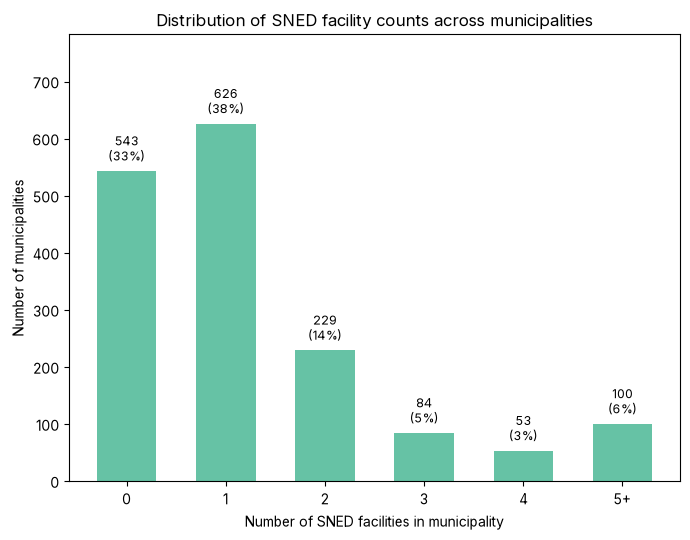

In [7]:
# Public+private population specifically for THIS chart 
muni_universe_pp = lgu_pp[["psgc_municity", "psgc_municity_name", "psgc_province_name", "psgc_region_name"]].drop_duplicates()
fac_by_muni_pp = muni_universe_pp.merge(fac_counts, on="psgc_municity", how="left")
fac_by_muni_pp[facility_cols] = fac_by_muni_pp[facility_cols].fillna(0).astype(int)

bins = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, np.inf]
labels = ["0", "1", "2", "3", "4", "5+"]
fac_by_muni_pp["n_any_facility_bucket"] = pd.cut(fac_by_muni_pp.n_any_facility, bins=bins, labels=labels)
bucket_counts_pp = fac_by_muni_pp.n_any_facility_bucket.value_counts().reindex(labels)

fig, ax = plt.subplots(figsize=(7, 5.5))  # taller -> headroom for annotations + title
ax.bar(bucket_counts_pp.index.astype(str), bucket_counts_pp.values, color=PASTEL[0], width=0.6)
ax.set_xlabel("Number of SNED facilities in municipality")
ax.set_ylabel("Number of municipalities")
ax.set_title("Distribution of SNED facility counts across municipalities")
for i, v in enumerate(bucket_counts_pp.values):
    ax.text(i, v + bucket_counts_pp.max() * 0.03, f"{v}\n({v/len(fac_by_muni_pp):.0%})", ha="center", fontsize=9)
ax.set_ylim(top=bucket_counts_pp.max() * 1.25)
plt.tight_layout()
# plt.savefig(_ROOT / "figures" / "facility_count_distribution_pubpriv.png", dpi=200, bbox_inches="tight")
plt.show()

In [8]:
# Areas with 4+ municipalities
four_plus_munis = fac_by_muni[fac_by_muni.n_any_facility >= 4]
region_four_plus = four_plus_munis.groupby("psgc_region_name").size().sort_values(ascending=False)
print(f"Municipalities with 4+ facilities: {len(four_plus_munis)} total")
region_four_plus

Municipalities with 4+ facilities: 153 total


psgc_region_name
Region IX (Zamboanga Peninsula)           26
Region XI (Davao Region)                  21
Region IV-A (CALABARZON)                  18
Region X (Northern Mindanao)              13
Region XIII (Caraga)                      12
National Capital Region (NCR)             12
Region VII (Central Visayas)              12
Region III (Central Luzon)                 9
MIMAROPA Region                            7
Cordillera Administrative Region (CAR)     5
Negros Island Region (NIR)                 5
Region XII (SOCCSKSARGEN)                  4
Region I (Ilocos Region)                   3
Region II (Cagayan Valley)                 2
Region VIII (Eastern Visayas)              2
Region V (Bicol Region)                    1
Region VI (Western Visayas)                1
dtype: int64

In [9]:
# Regional and provincial aggregates
region_agg = add_region_short(roster, "psgc_region_name").groupby(
    "region_short", observed=True
).agg(
    n_ilrc=("is_ilrc", "sum"),
    n_sned=("is_sned", "sum"),
    n_sped_center=("is_sped_center", "sum"),
    total_facilities=("is_any_facility", "sum"),
).reindex(REGION_ORDER)
region_agg['total_facilities_share'] = np.round(
    region_agg['total_facilities'] / region_agg['total_facilities'].sum() * 100, 2
)

province_agg = (
    roster.groupby(["psgc_region_name", "psgc_province_name"], as_index=False)
    .agg(
        n_ilrc=("is_ilrc", "sum"),
        n_sned=("is_sned", "sum"),
        n_sped_center=("is_sped_center", "sum"),
        total_facilities=("is_any_facility", "sum"),
    )
    .sort_values("total_facilities", ascending=False)
)
province_agg['total_facilities_share'] = np.round(
    province_agg['total_facilities'] / province_agg['total_facilities'].sum() * 100, 2
)
print("Region:")
display(region_agg)
print("Province:")
display(province_agg.head(10))



Region:


,n_ilrc,n_sned,n_sped_center,total_facilities,total_facilities_share
region_short,,,,,
Ilocos Region,4,94,35,113,4.30
Cagayan Valley,3,67,23,74,2.82
CAR,3,54,10,60,2.29
Central Luzon,3,189,43,203,7.73
NCR,4,131,31,150,5.71
CALABARZON,4,260,69,285,10.86
MIMAROPA,3,132,12,139,5.30
Bicol Region,4,121,17,131,4.99
Western Visayas,4,76,22,92,3.50


Province:


,psgc_region_name,psgc_province_name,n_ilrc,n_sned,n_sped_center,total_facilities,total_facilities_share
66,Region IX (Zamboanga Peninsula),Zamboanga del Norte,0,210,16,222,8.46
81,Region VII (Central Visayas),Cebu,1,106,25,116,4.42
99,Region XI (Davao Region),City of Davao,1,88,8,90,3.43
43,Region I (Ilocos Region),Pangasinan,2,62,22,73,2.78
103,Region XI (Davao Region),Davao del Norte,1,65,6,70,2.67
101,Region XI (Davao Region),Davao Oriental,2,68,2,68,2.59
61,Region IV-A (CALABARZON),Quezon,0,59,15,67,2.55
57,Region IV-A (CALABARZON),Batangas,1,56,7,62,2.36
92,Region X (Northern Mindanao),Bukidnon,1,53,7,58,2.21
16,MIMAROPA Region,Oriental Mindoro,1,56,2,58,2.21


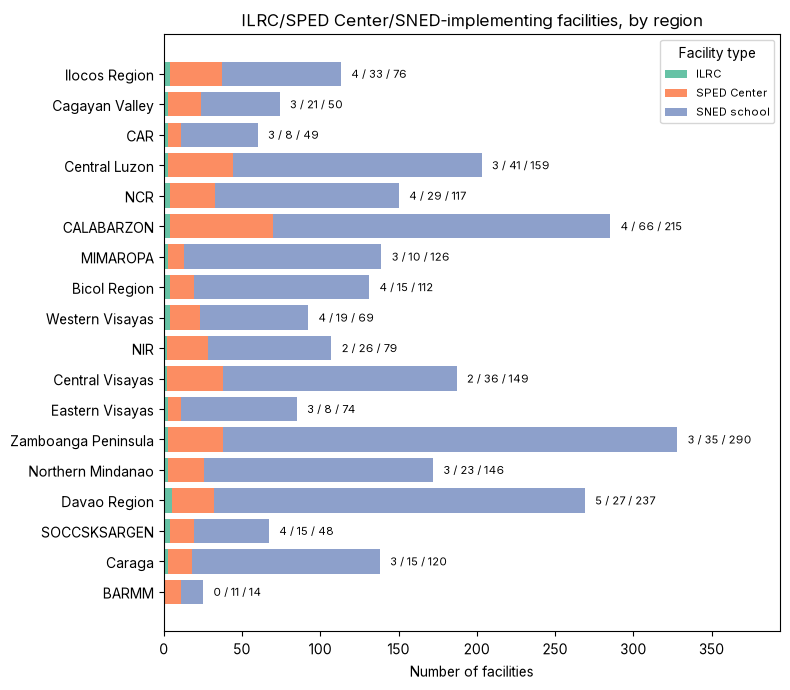

In [10]:
# Deduplicate by precedence: a facility holding multiple roles counts toward the highest-priority one only (ILRC > SPED Center > SNED school)
roster["facility_type_dedup"] = np.select(
    [roster.is_ilrc, roster.is_sped_center, roster.is_sned],
    ["ILRC", "SPED Center", "SNED school"],
    default=None,
)
n_unclassified = roster["facility_type_dedup"].isna().sum()
if n_unclassified:
    print(f"NOTE: {n_unclassified} roster row(s) hold none of the three roles -- excluded from this chart.")

region_agg_dedup = (
    add_region_short(roster, "psgc_region_name")
    .groupby("region_short", observed=True)["facility_type_dedup"]
    .value_counts()
    .unstack(fill_value=0)
    .reindex(REGION_ORDER)
    .reindex(columns=["ILRC", "SPED Center", "SNED school"], fill_value=0)
)

fig, ax = plt.subplots(figsize=(8, 7))
bottom = np.zeros(len(region_agg_dedup))
for i, col in enumerate(["ILRC", "SPED Center", "SNED school"]):
    ax.barh(region_agg_dedup.index.astype(str), region_agg_dedup[col], left=bottom, label=col, color=PASTEL[i])
    bottom += region_agg_dedup[col].values

# one "# / # / #" annotation at the end of each full stacked bar
for i in range(len(region_agg_dedup)):
    row = region_agg_dedup.iloc[i]
    ax.text(bottom[i] + bottom.max() * 0.02, i,
            f"{int(row['ILRC'])} / {int(row['SPED Center'])} / {int(row['SNED school'])}",
            va="center", fontsize=8)

ax.set_xlabel("Number of facilities")
ax.set_title("ILRC/SPED Center/SNED-implementing facilities, by region")
ax.legend(title="Facility type", fontsize=8)
ax.invert_yaxis()
ax.set_xlim(right=bottom.max() * 1.2)
plt.tight_layout()
# plt.savefig(_ROOT / "figures" / "facilities_by_region.png", dpi=200, bbox_inches="tight")
plt.show()

In [11]:
top_munis = fac_by_muni.sort_values("n_any_facility", ascending=False).head(15)
top_munis[["psgc_municity_name", "psgc_province_name", "n_ilrc", "n_sped_center", "n_sned", "n_any_facility"]]

,psgc_municity_name,psgc_province_name,n_ilrc,n_sped_center,n_sned,n_any_facility
0,City of Davao,City of Davao,1,8,88,90
1513,Quezon City,Quezon City,1,7,38,42
2,City of Zamboanga,City of Zamboanga,1,7,29,31
214,City of Cagayan De Oro,City of Cagayan De Oro,1,6,28,30
526,Sindangan,Zamboanga del Norte,0,1,24,25
1279,City of Calapan,Oriental Mindoro,1,0,20,21
1192,Sergio Osmeña Sr.,Zamboanga del Norte,0,2,19,21
1517,City of Naga,Camarines Sur,0,2,18,20
863,City of San Carlos,Pangasinan,0,2,18,20
1631,City of Valenzuela,City of Valenzuela,0,0,19,19


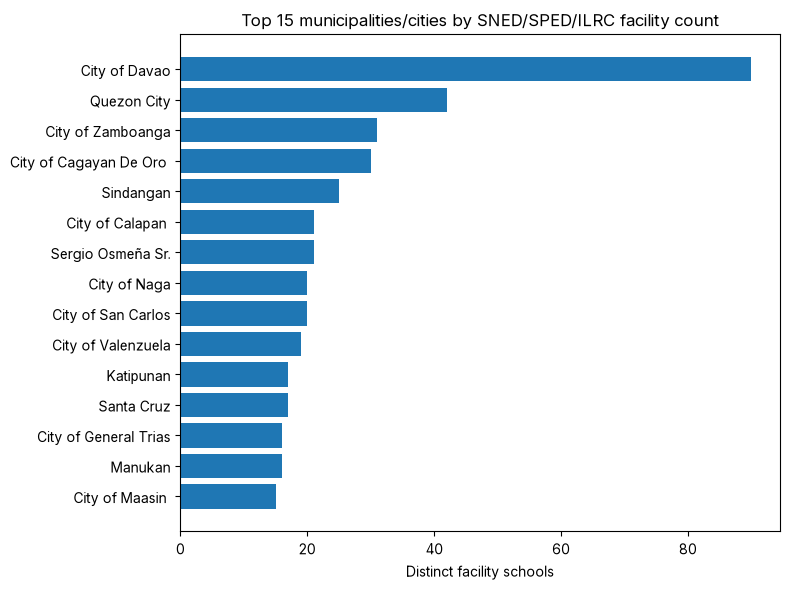

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_munis.psgc_municity_name, top_munis.n_any_facility)
ax.set_xlabel("Distinct facility schools")
ax.set_title("Top 15 municipalities/cities by SNED/SPED/ILRC facility count")
ax.invert_yaxis()
plt.tight_layout()
# plt.savefig(_ROOT / "figures" / "top_munis_facility_count.png", dpi=200, bbox_inches="tight")
plt.show()

In [13]:
# Satellite-school reach per facility
def satellite_school_stats(pairs_df):
    """Descriptive stats of how many OTHER schools (satellites) fall within 3km of each
    facility. Facilities that generated zero rows in `pairs_df` at all (unroutable
    coordinates -- see roster.coord_status) are excluded here, since a missing row means
    "we couldn't compute a distance," not "zero satellites" -- these two must not be
    conflated when reporting a minimum of 0."""
    is_host = pairs_df.facility_school_id == pairs_df.population_school_id
    sat_counts = (
        pairs_df[~is_host].groupby("facility_school_id")["population_school_id"].nunique()
    )
    fac_names = pairs_df[["facility_school_id", "facility_school_name"]].drop_duplicates().set_index("facility_school_id")
    sat_full = sat_counts.reindex(fac_names.index, fill_value=0).rename("n_satellite_schools")
    return fac_names.join(sat_full).reset_index()

satellite_stats_pp  = satellite_school_stats(pp_pairs)
satellite_stats_pub = satellite_school_stats(pub_pairs)

def summarize_satellite_stats(stats_df, label):
    desc = stats_df.n_satellite_schools.describe()[["mean", "50%", "min", "max"]].rename({"50%": "median"})
    max_row = stats_df.loc[stats_df.n_satellite_schools.idxmax()]
    min_val = stats_df.n_satellite_schools.min()
    min_rows = stats_df[stats_df.n_satellite_schools == min_val]
    print(f"--- {label} ---")
    print(desc.round(1))
    print(f"Max: {max_row.facility_school_name} ({int(max_row.n_satellite_schools)} satellite schools)")
    print(f"Min ({int(min_val)} satellites, n={len(min_rows)} facilities): "
          f"{min_rows.facility_school_name.tolist()[:5]}"
          f"{' ... (+' + str(len(min_rows)-5) + ' more)' if len(min_rows) > 5 else ''}")
    print(f"n facilities included: {len(stats_df)} of {len(roster)} "
          f"({len(roster) - len(stats_df)} excluded -- unroutable coordinates, see coord_status)")
    print()

summarize_satellite_stats(satellite_stats_pp, "Public + Private population (pp_pairs)")
summarize_satellite_stats(satellite_stats_pub, "Public-only population (pub_pairs)")

--- Public + Private population (pp_pairs) ---
mean       9.9
median     5.0
min        0.0
max       99.0
Name: n_satellite_schools, dtype: float64
Max: Caloocan Central Elementary School (99 satellite schools)
Min (0 satellites, n=194 facilities): ['Magnuang ES', 'Maipalig-Quiom ES', 'Nagsabaran Sur ES', 'Maliga ES', 'Pinalpal Elementary School'] ... (+189 more)
n facilities included: 2618 of 2629 (11 excluded -- unroutable coordinates, see coord_status)

--- Public-only population (pub_pairs) ---
mean       5.6
median     4.0
min        0.0
max       52.0
Name: n_satellite_schools, dtype: float64
Max: J. P. Rizal Elementary School (52 satellite schools)
Min (0 satellites, n=206 facilities): ['Magnuang ES', 'Maipalig-Quiom ES', 'Nagsabaran Sur ES', 'Maliga ES', 'Pinalpal Elementary School'] ... (+201 more)
n facilities included: 2618 of 2629 (11 excluded -- unroutable coordinates, see coord_status)



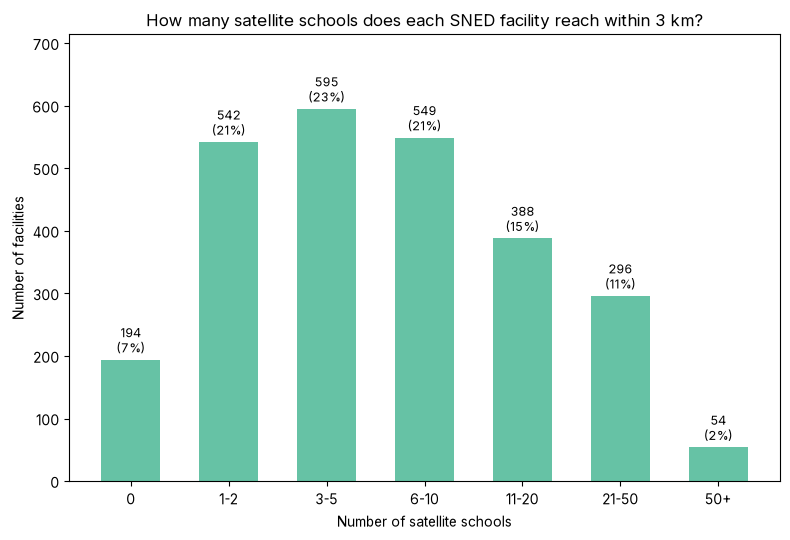

In [14]:
sat_bins = [-0.5, 0.5, 2.5, 5.5, 10.5, 20.5, 50.5, np.inf]
sat_labels = ["0", "1-2", "3-5", "6-10", "11-20", "21-50", "50+"]
satellite_stats_pp["bucket"] = pd.cut(satellite_stats_pp.n_satellite_schools, bins=sat_bins, labels=sat_labels)
bucket_counts_sat = satellite_stats_pp.bucket.value_counts().reindex(sat_labels)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.bar(bucket_counts_sat.index.astype(str), bucket_counts_sat.values, color=PASTEL[0], width=0.6)
ax.set_xlabel("Number of satellite schools")
ax.set_ylabel("Number of facilities")
ax.set_title("How many satellite schools does each SNED facility reach within 3 km?")
for i, v in enumerate(bucket_counts_sat.values):
    ax.text(i, v + bucket_counts_sat.max() * 0.02, f"{v}\n({v/len(satellite_stats_pp):.0%})", ha="center", fontsize=9)
ax.set_ylim(top=bucket_counts_sat.max() * 1.2)
plt.tight_layout()
plt.show()


### **C. Disability Profiles**

In [15]:
# Aggregating SNED database to school level
school_disability_long = con.execute(f"""
    SELECT beis_school_id, School_name AS school_name, Diagnosis_Type, Category, SUM(Learner_Count) AS n_learners
    FROM read_parquet('{PARQUET_PATH.as_posix()}')
    WHERE Learner_Count > 0          -- safe pre-filter: drops empty combinatorial cells before
                                      -- the GROUP BY, shrinking the number of groups DuckDB has
                                      -- to hash without changing any result (adding zeros is a no-op)
    GROUP BY beis_school_id, School_name, Diagnosis_Type, Category
""").df()


print(f"Distinct schools with ≥ 1 identified SNED learner: {school_disability_long.beis_school_id.nunique():,}")
print(f"Total identified SNED learners nationally: {school_disability_long.n_learners.sum():,.0f}")

Distinct schools with ≥ 1 identified SNED learner: 38,348
Total identified SNED learners nationally: 523,939


In [16]:
# Diagnosed vs. manifestation counts per school
diag_wide = (
    school_disability_long
    .groupby(["beis_school_id", "Diagnosis_Type"], as_index=False)["n_learners"].sum()
    .pivot(index="beis_school_id", columns="Diagnosis_Type", values="n_learners")
    .fillna(0)
)
diag_wide.columns.name = None
diag_wide = diag_wide.rename(columns={
    "With Diagnosis from Licensed Medical Specialist": "n_diagnosed",
    "With Manifestations": "n_manifestation",
}).reset_index()
for col in ["n_diagnosed", "n_manifestation"]:
    if col not in diag_wide.columns:
        diag_wide[col] = 0

school_totals = diag_wide[["beis_school_id", "n_diagnosed", "n_manifestation"]].copy()
school_totals["total_learners"] = school_totals.n_diagnosed + school_totals.n_manifestation

# school_disability_long carries one school_name per beis_school_id
school_names = school_disability_long[["beis_school_id", "school_name"]].drop_duplicates(subset="beis_school_id")
school_totals = school_totals.merge(school_names, on="beis_school_id", how="left")
school_totals.head()

,beis_school_id,n_diagnosed,n_manifestation,total_learners,school_name
0,100002,0.0,4.0,4.0,Bacarra CES
1,100003,0.0,13.0,13.0,Buyon ES
2,100004,1.0,0.0,1.0,Ganagan Elementary School
3,100007,0.0,6.0,6.0,Pasiocan ES
4,100008,0.0,2.0,2.0,Pulangi ES


In [17]:
# Reconciling facility roster against the learner database
facility_ids_in_db = roster.merge(school_totals, left_on="school_id", right_on="beis_school_id", how="inner")
n_facilities_matched = facility_ids_in_db.beis_school_id.nunique()

total_learners_in_facilities = facility_ids_in_db.total_learners.sum()
total_learners_nationally = school_disability_long.n_learners.sum()

print(f"Facilities matched to the SNED database: {n_facilities_matched} of {len(roster)} "
      f"({len(roster) - n_facilities_matched} excluded -- see the unmatched_facilities table in cell 3)")
print(f"Total SNED learners contained in SNED facilities: {total_learners_in_facilities:,.0f}")
print(f"Total SNED learners in the SNED database (all schools, not just facilities): {total_learners_nationally:,.0f}")
print(f"Facilities' share of the national total: {total_learners_in_facilities/total_learners_nationally:.1%}")



Facilities matched to the SNED database: 2588 of 2629 (41 excluded -- see the unmatched_facilities table in cell 3)
Total SNED learners contained in SNED facilities: 153,383
Total SNED learners in the SNED database (all schools, not just facilities): 523,939
Facilities' share of the national total: 29.3%


In [18]:
# The 12 (cell 3's definition) -- already computed, no new query needed.
print(f"Genuinely absent from the SNED database: {len(unmatched_facilities)}")
display(unmatched_facilities)

# The extra 29: present in the parquet, but Learner_Count == 0 in every row for that school.
all_ids_in_parquet = con.execute(f"""
    SELECT DISTINCT beis_school_id FROM read_parquet('{PARQUET_PATH.as_posix()}')
""").df().beis_school_id

present_but_all_zero = roster[
    roster.school_id.isin(all_ids_in_parquet) & ~roster.school_id.isin(school_totals.beis_school_id)
]
print(f"\nIn the database, but reporting zero identified SNED learners in every category: {len(present_but_all_zero)}")
present_but_all_zero[["school_id", "school_name", "psgc_region_name", "psgc_province_name",
                       "psgc_municity_name", "is_ilrc", "is_sned", "is_sped_center"]]

Genuinely absent from the SNED database: 12


,school_id,school_name,psgc_region_name,psgc_province_name,psgc_municity_name,is_ilrc,is_sned,is_sped_center,coord_status
0,136690,Makati ES,National Capital Region (NCR),City of Makati,City of Makati,False,True,False,valid
1,136710,Nemesio I. Yabut ES,National Capital Region (NCR),City of Makati,City of Makati,False,True,False,valid
2,107287,Calaca Central School,Region IV-A (CALABARZON),Batangas,City of Calaca,False,True,False,valid
3,108473,Dita Elementary School,Region IV-A (CALABARZON),Laguna,City of Santa Rosa,False,True,True,valid
4,109255,Kalumpang Elementary School,Region IV-A (CALABARZON),Quezon,City of Tayabas,False,True,True,valid
5,124618,Kalucap ES,Region IX (Zamboanga Peninsula),Zamboanga del Norte,Salug,False,True,False,valid
6,112134,Daet Elementary School,Region V (Bicol Region),Camarines Norte,Daet,True,False,True,valid
7,130453,Congan Elementary School,Region XII (SOCCSKSARGEN),Sarangani,Glan,False,True,False,valid
8,119412,Jubay Elementary School,NaN,NaN,NaN,False,True,False,valid
9,129443,A.S. Manjoorsa Elementary School,NaN,NaN,NaN,False,True,False,valid



In the database, but reporting zero identified SNED learners in every category: 29


,school_id,school_name,psgc_region_name,psgc_province_name,psgc_municity_name,is_ilrc,is_sned,is_sped_center
90,102314,Tukon Elementary School,Region II (Cagayan Valley),Batanes,Basco,False,True,False
105,102771,New Orlins ES,Region II (Cagayan Valley),Cagayan,Lasam,False,False,True
211,105233,Sta. Rita Elementary School,Region III (Central Luzon),Nueva Ecija,Cabiao,False,True,True
254,105912,Balas ES,Region III (Central Luzon),Pampanga,Bacolor,False,True,False
639,110447,Malayong ES,MIMAROPA Region,Oriental Mindoro,Gloria,False,True,False
673,110974,Bayo Bayo Elementary School,MIMAROPA Region,Palawan,Coron,False,True,False
759,112200,Bagong Silang III Elementary School,Region V (Bicol Region),Camarines Norte,Labo,False,True,False
855,115148,Bonifacio Gella Candari Elementary School,Region VI (Western Visayas),Antique,Pandan,False,True,False
947,117296,San Miguel ES,Negros Island Region (NIR),Negros Occidental,Murcia,False,True,False
996,118288,Cansuhay Elementary School,Region VII (Central Visayas),Bohol,Duero,False,True,False


In [21]:
# Total SNED per school. top disabilities
top_category = (
    school_disability_long
    .sort_values("n_learners", ascending=False)
    .drop_duplicates(subset=["beis_school_id", "Diagnosis_Type"], keep="first")
    .rename(columns={"Category": "top_category", "n_learners": "top_category_n_learners"})
    [["beis_school_id", "Diagnosis_Type", "top_category", "top_category_n_learners"]]
)

top_category_wide = (
    top_category
    .pivot(index="beis_school_id", columns="Diagnosis_Type", values=["top_category", "top_category_n_learners"])
)
top_category_wide.columns = ["_".join(c) for c in top_category_wide.columns]
top_category_wide = top_category_wide.rename(columns={
    "top_category_With Diagnosis from Licensed Medical Specialist": "top_diagnosed_category",
    "top_category_With Manifestations": "top_manifestation_category",
    "top_category_n_learners_With Diagnosis from Licensed Medical Specialist": "top_diagnosed_n",
    "top_category_n_learners_With Manifestations": "top_manifestation_n",
}).reset_index()

school_totals = school_totals.merge(top_category_wide, on="beis_school_id", how="left")

# National-level version: which category is most common overall (not per-school)
national_top_category = (
    school_disability_long.groupby(["Diagnosis_Type", "Category"])["n_learners"].sum()
    .sort_values(ascending=False)
)
print("Top 3 disability categories nationally, by diagnosis type:")
print(national_top_category.groupby("Diagnosis_Type", group_keys=False).head(5))
print()

school_totals.sort_values("total_learners", ascending=False).head(5)

Top 3 disability categories nationally, by diagnosis type:
Diagnosis_Type                                   Category                                                                    
With Manifestations                              Difficulty in Remembering, Concentrating, Paying Attention and Understanding    172837.0
With Diagnosis from Licensed Medical Specialist  Autism Spectrum Disorder                                                         77217.0
With Manifestations                              Difficulty in Applying Knowledge                                                 59311.0
With Diagnosis from Licensed Medical Specialist  Intellectual Disability                                                          37019.0
With Manifestations                              Difficulty in Seeing                                                             31793.0
With Diagnosis from Licensed Medical Specialist  Learning Disability                                                         

,beis_school_id,n_diagnosed,n_manifestation,total_learners,school_name,top_diagnosed_category_x,top_manifestation_category_x,top_diagnosed_n_x,top_manifestation_n_x,top_diagnosed_category_y,top_manifestation_category_y,top_diagnosed_n_y,top_manifestation_n_y,top_diagnosed_category,top_manifestation_category,top_diagnosed_n,top_manifestation_n
36535,500334,478.0,334.0,812.0,Jose Fabella Memorial School,Emotional-Behavioral Disorder,Difficulty in Displaying Inter-Personal Behavior,206.0,129.0,Emotional-Behavioral Disorder,Difficulty in Displaying Inter-Personal Behavior,206.0,129.0,Emotional-Behavioral Disorder,Difficulty in Displaying Inter-Personal Behavior,206.0,129.0
36510,500302,612.0,185.0,797.0,General Santos City SPED Integrated School,Autism Spectrum Disorder,"Difficulty in Remembering, Concentrating, Payi...",369.0,79.0,Autism Spectrum Disorder,"Difficulty in Remembering, Concentrating, Payi...",369.0,79.0,Autism Spectrum Disorder,"Difficulty in Remembering, Concentrating, Payi...",369.0,79.0
22100,136432,657.0,48.0,705.0,J. P. Rizal Elementary School,Autism Spectrum Disorder,"Difficulty in Remembering, Concentrating, Payi...",350.0,25.0,Autism Spectrum Disorder,"Difficulty in Remembering, Concentrating, Payi...",350.0,25.0,Autism Spectrum Disorder,"Difficulty in Remembering, Concentrating, Payi...",350.0,25.0
29117,307812,73.0,542.0,615.0,Governor Luis A. Ferrer Jr. East National High...,Hearing Impairment,Difficulty in Seeing,26.0,453.0,Hearing Impairment,Difficulty in Seeing,26.0,453.0,Hearing Impairment,Difficulty in Seeing,26.0,453.0
36530,500329,600.0,6.0,606.0,Philippine School for the Deaf,Hearing Impairment,Difficulty in Hearing,590.0,6.0,Hearing Impairment,Difficulty in Hearing,590.0,6.0,Hearing Impairment,Difficulty in Hearing,590.0,6.0


### **D. Municipalities and Schools without 3km access**

In [22]:
# SNED desert - municipalities that contain zero ILRC / SPED Center / SNED-implementing school in own boundaries
def desert_aggregate(lgu_pub, lgu_pp, group_col):
    d_pub = lgu_pub[lgu_pub.lgu_has_no_facility_at_all].groupby(group_col).size().rename("n_desert_pub")
    d_pp  = lgu_pp[lgu_pp.lgu_has_no_facility_at_all].groupby(group_col).size().rename("n_desert_pp")
    tbl = pd.concat([d_pub, d_pp], axis=1).fillna(0).astype(int)
    tbl["total_munis"] = lgu_pp.groupby(group_col).size()  # pp universe is the superset (see note below)
    tbl["pct_desert_pp"] = tbl.n_desert_pp / tbl.total_munis
    return tbl.sort_values("n_desert_pp", ascending=False)

desert_by_province = desert_aggregate(lgu_pub, lgu_pp, "psgc_province_name")
desert_by_region   = desert_aggregate(lgu_pub, lgu_pp, "psgc_region_name")

print("Raw counts (public+private definition shown as primary; public-only alongside for comparison)")
print(f"Total 'desert' municipalities -- pubpriv def.: {lgu_pp.lgu_has_no_facility_at_all.sum()} of {len(lgu_pp)} "
      f"({lgu_pp.lgu_has_no_facility_at_all.mean():.1%})")
print(f"Total 'desert' municipalities -- public-only def.: {lgu_pub.lgu_has_no_facility_at_all.sum()} of {len(lgu_pub)} "
      f"({lgu_pub.lgu_has_no_facility_at_all.mean():.1%})")
print("Note: the pubpriv universe has exactly one more municipality than the public-only universe "
      "(Binondo, Manila) -- it has zero public schools on record, only a private one, so it is invisible "
      "to the public-only analysis entirely. This single municipality accounts for the +1 desert-count "
      "difference above; it is not a data error.")
print()
print("By province (top 10 by absolute count):")
display(desert_by_province.head(10))
print()
print("By region (all regions, ranked):")
display(desert_by_region)

Raw counts (public+private definition shown as primary; public-only alongside for comparison)
Total 'desert' municipalities -- pubpriv def.: 543 of 1635 (33.2%)
Total 'desert' municipalities -- public-only def.: 542 of 1634 (33.2%)
Note: the pubpriv universe has exactly one more municipality than the public-only universe (Binondo, Manila) -- it has zero public schools on record, only a private one, so it is invisible to the public-only analysis entirely. This single municipality accounts for the +1 desert-count difference above; it is not a data error.

By province (top 10 by absolute count):


,n_desert_pub,n_desert_pp,total_munis,pct_desert_pp
psgc_province_name,,,,
Lanao del Sur,37,37,40,0.925000
Abra,26,26,27,0.962963
Samar,23,23,26,0.884615
Maguindanao del Sur,22,22,24,0.916667
Ilocos Sur,22,22,34,0.647059
Isabela,21,21,37,0.567568
Eastern Samar,20,20,23,0.869565
Northern Samar,20,20,24,0.833333
Leyte,19,19,42,0.452381



By region (all regions, ranked):


,n_desert_pub,n_desert_pp,total_munis,pct_desert_pp
psgc_region_name,,,,
Bangsamoro Autonomous Region In Muslim Mindanao (BARMM),94,94,108,0.870370
Region VIII (Eastern Visayas),90,90,143,0.629371
Region I (Ilocos Region),61,61,125,0.488000
Cordillera Administrative Region (CAR),45,45,77,0.584416
Region II (Cagayan Valley),43,43,93,0.462366
Region V (Bicol Region),34,34,114,0.298246
Region VI (Western Visayas),30,30,101,0.297030
Region X (Northern Mindanao),26,26,93,0.279570
MIMAROPA Region,25,25,72,0.347222


Municipality polygons with no matching lgu_pp row: 21 of 1582


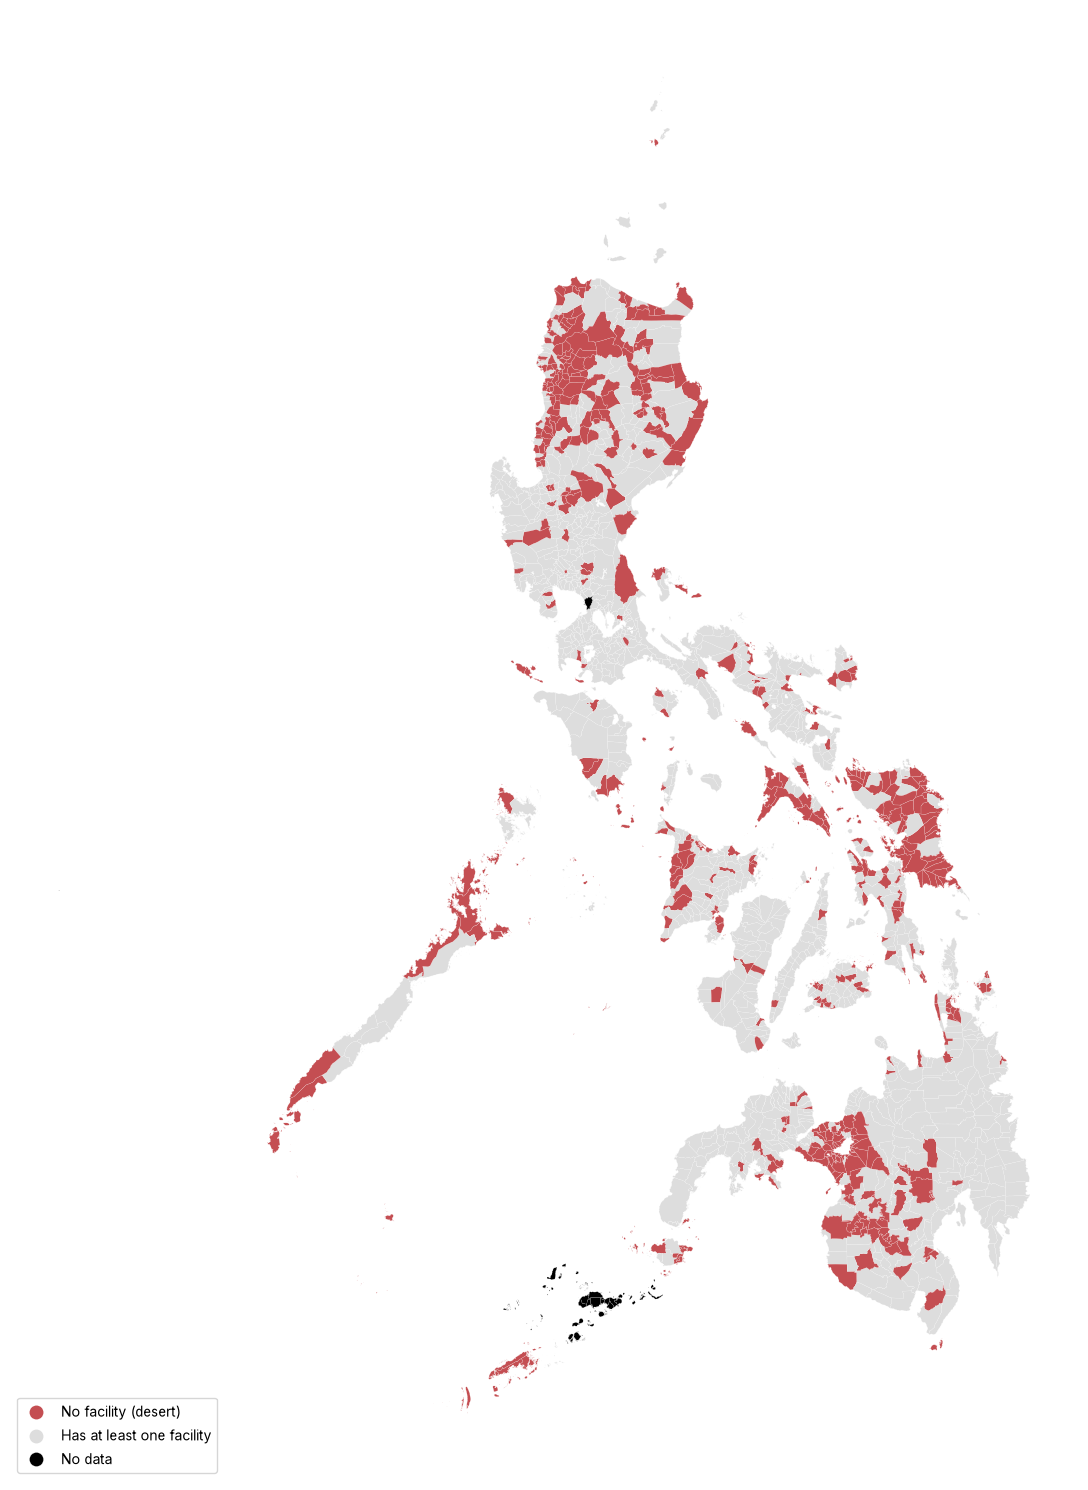

In [23]:
def to_psgc_str(series):
    return series.dropna().astype('int64').astype(str).str.zfill(10)

brgy = gpd.read_file(DATA / "external" / "consolidated_geodata_matched.gpkg")

# Fix NIR
NIR_PROVINCES = {"Negros Occidental", "Negros Oriental", "Siquijor"}
is_nir = brgy["adm2_en"].isin(NIR_PROVINCES)
brgy.loc[is_nir, "adm1_en"] = "Negros Island Region (NIR)"
brgy.loc[is_nir, "adm3_psgc"] = "18" + brgy.loc[is_nir, "adm3_psgc"].str[2:]
brgy.loc[is_nir, "adm2_psgc"] = "18" + brgy.loc[is_nir, "adm2_psgc"].str[2:]

muni_shapes = brgy.dissolve(by="adm3_psgc", aggfunc={"adm2_en": "first", "adm1_en": "first", "adm3_en": "first"})
muni_shapes = muni_shapes.reset_index().rename(columns={"adm3_psgc": "psgc_municity"})

lgu_pp["psgc_municity_str"] = to_psgc_str(lgu_pp["psgc_municity"])
desert_choropleth_df = muni_shapes.merge(
    lgu_pp[["psgc_municity_str", "lgu_has_no_facility_at_all", "psgc_region_name"]],
    left_on="psgc_municity", right_on="psgc_municity_str", how="left"
)

n_unmatched_geo = desert_choropleth_df.lgu_has_no_facility_at_all.isna().sum()
print(f"Municipality polygons with no matching lgu_pp row: {n_unmatched_geo} of {len(desert_choropleth_df)}")

desert_choropleth_df["desert_label"] = pd.Categorical(
    desert_choropleth_df.lgu_has_no_facility_at_all.map(
        {True: "No facility (desert)", False: "Has at least one facility"}
    ),
    categories=["No facility (desert)", "Has at least one facility"]
)

fig, ax = plt.subplots(figsize=(11, 15))  # larger
desert_choropleth_df.plot(
    column="desert_label", categorical=True, cmap=ListedColormap(["#C44E52", "#DDDDDD"]), legend=True,
    edgecolor="white", linewidth=0.1, ax=ax,
    missing_kwds={"color": "black", "label": "No data"},
    legend_kwds={"loc": "lower left"},
)
ax.set_axis_off()
plt.tight_layout()
# plt.savefig(_ROOT / "figures" / "desert_choropleth.png", dpi=200, bbox_inches="tight")
plt.show()

In [24]:
# Coverage classification
# A municipality can be a "desert" by the boundary definition above and still have its schools reached by a neighboring municipality's facility within 3km 
def classify_coverage(row):
    if row["n_population_schools"] == 0:
        return "No schools"
    elif row["pct_without_access"] == 0:
        return "Full coverage"
    elif row["pct_without_access"] == 1:
        return "Zero coverage"
    else:
        return "Partial coverage"

lgu_pub["coverage_class"] = lgu_pub.apply(classify_coverage, axis=1)
lgu_pp["coverage_class"]  = lgu_pp.apply(classify_coverage, axis=1)

print("Coverage classification (public-school population):")
print(lgu_pub.coverage_class.value_counts())
print()

# The nuance: a municipality with NO facility inside it can still show partial/full
# coverage (a neighboring municipality's facility reaches across the border within 3km),
# and a municipality WITH a facility inside it can still show zero/partial coverage
# (the muni is geographically large, or has schools far from its own facility).
boundary_vs_radius = pd.crosstab(
    lgu_pub["lgu_has_no_facility_at_all"].map({True: "No facility in muni", False: "Has facility in muni"}),
    lgu_pub["coverage_class"]
)
print("Public-school population:")
display(boundary_vs_radius)

# Same crosstab against the public+private population 
boundary_vs_radius_pp = pd.crosstab(
    lgu_pp["lgu_has_no_facility_at_all"].map({True: "No facility in muni", False: "Has facility in muni"}),
    lgu_pp["coverage_class"]
)
print("Public+private population:")
display(boundary_vs_radius_pp)

Coverage classification (public-school population):
coverage_class
Partial coverage    1130
Zero coverage        474
Full coverage         30
Name: count, dtype: int64

Public-school population:


coverage_class,Full coverage,Partial coverage,Zero coverage
lgu_has_no_facility_at_all,,,
Has facility in muni,25,1066,1
No facility in muni,5,64,473


Public+private population:


coverage_class,Full coverage,Partial coverage,Zero coverage
lgu_has_no_facility_at_all,,,
Has facility in muni,21,1070,1
No facility in muni,5,66,472


In [25]:
partial_none_df = lgu_pp[(lgu_pp["lgu_has_no_facility_at_all"] == True) & (lgu_pp["coverage_class"] == "Partial coverage")]
partial_none_df[partial_none_df["psgc_province_name"].str.contains("Leyte")]

,psgc_municity,psgc_municity_name,psgc_province_name,psgc_region_name,n_population_schools,n_with_access,n_without_access,pct_without_access,lgu_has_no_facility_at_all,psgc_municity_str,coverage_class
228,803706000,Barugo,Leyte,Region VIII (Eastern Visayas),39,1,38,0.974,True,0803706000,Partial coverage
389,803734000,Matalom,Leyte,Region VIII (Eastern Visayas),32,2,30,0.938,True,0803734000,Partial coverage
449,806412000,Saint Bernard,Southern Leyte,Region VIII (Eastern Visayas),31,3,28,0.903,True,0806412000,Partial coverage
485,803724000,Javier,Leyte,Region VIII (Eastern Visayas),28,1,27,0.964,True,0803724000,Partial coverage
675,803720000,Hindang,Leyte,Region VIII (Eastern Visayas),23,1,22,0.957,True,0803720000,Partial coverage
929,803744000,Santa Fe,Leyte,Region VIII (Eastern Visayas),19,2,17,0.895,True,0803744000,Partial coverage


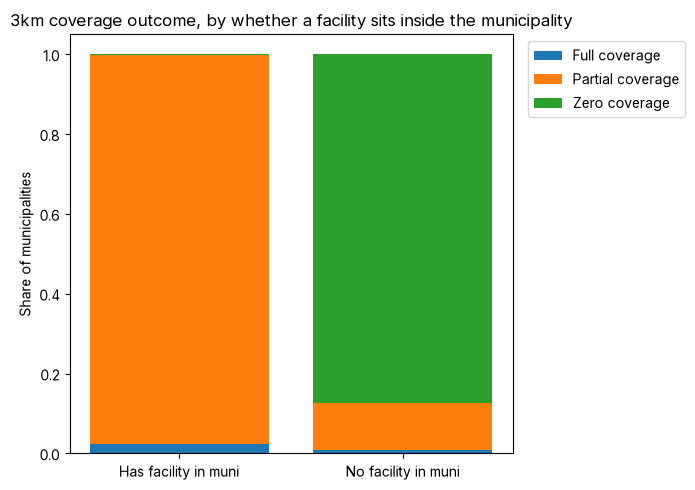

In [26]:
boundary_pct = boundary_vs_radius.div(boundary_vs_radius.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(7, 5))
bottom = np.zeros(len(boundary_pct))
for col in boundary_pct.columns:
    ax.bar(boundary_pct.index, boundary_pct[col], bottom=bottom, label=col)
    bottom += boundary_pct[col].values
ax.set_ylabel("Share of municipalities")
ax.set_title("3km coverage outcome, by whether a facility sits inside the municipality")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
# plt.savefig(_ROOT / "figures" / "boundary_vs_radius_coverage.png", dpi=200, bbox_inches="tight")
plt.show()



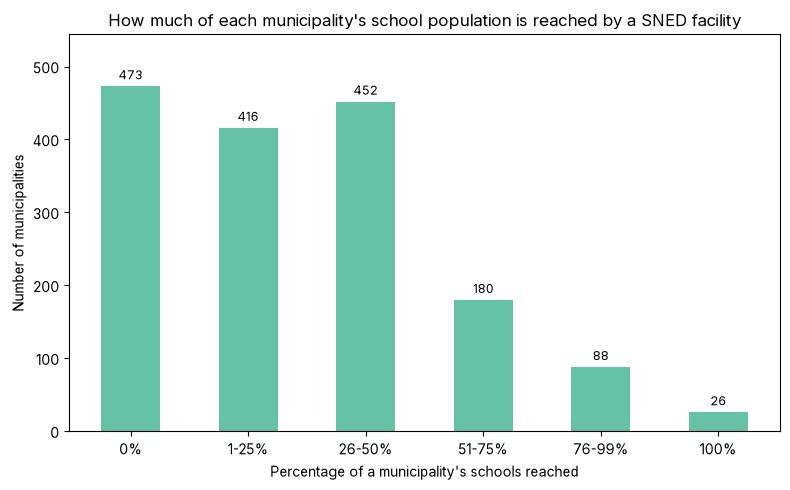

,psgc_municity_name,psgc_province_name,psgc_region_name,n_with_access,n_population_schools,reach_ratio,n_unreached,ratio_bucket
0,City of Davao,City of Davao,Region XI (Davao Region),323,569,0.567663,246,51-75%
1,City of Calbayog,Samar,Region VIII (Eastern Visayas),21,176,0.119318,155,1-25%
2,City of Zamboanga,City of Zamboanga,Region IX (Zamboanga Peninsula),140,266,0.526316,126,51-75%
3,City of Butuan,City of Butuan,Region XIII (Caraga),58,177,0.327684,119,26-50%
4,City of Puerto Princesa,City of Puerto Princesa,MIMAROPA Region,20,129,0.155039,109,1-25%
5,City of Surigao,Surigao del Norte,Region XIII (Caraga),2,107,0.018692,105,1-25%
6,City of Cabanatuan,Nueva Ecija,Region III (Central Luzon),8,100,0.080000,92,1-25%
7,San Jose,Occidental Mindoro,MIMAROPA Region,1,92,0.010870,91,1-25%
8,City of Kabankalan,Negros Occidental,Negros Island Region (NIR),17,106,0.160377,89,1-25%
9,City of Lapu-Lapu,City of Lapu-Lapu,Region VII (Central Visayas),22,110,0.200000,88,1-25%


In [27]:
# Reach ratio, how much of each municipality is actually served
reach_ratio = lgu_pp[["psgc_municity_name", "psgc_province_name", "psgc_region_name",
                      "n_with_access", "n_population_schools"]].copy()
reach_ratio["reach_ratio"] = reach_ratio.n_with_access / reach_ratio.n_population_schools
reach_ratio["n_unreached"] = reach_ratio.n_population_schools - reach_ratio.n_with_access

ratio_bins = [-0.01, 0.0, 0.25, 0.5, 0.75, 0.999, 1.0]
ratio_labels = ["0%", "1-25%", "26-50%", "51-75%", "76-99%", "100%"]
reach_ratio["ratio_bucket"] = pd.cut(reach_ratio.reach_ratio, bins=ratio_bins, labels=ratio_labels)
bucket_counts_reach = reach_ratio.ratio_bucket.value_counts().reindex(ratio_labels)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(bucket_counts_reach.index.astype(str), bucket_counts_reach.values, color=PASTEL[0], width=0.5)
ax.set_xlabel("Percentage of a municipality's schools reached")
ax.set_ylabel("Number of municipalities")
ax.set_title("How much of each municipality's school population is reached by a SNED facility")
for i, v in enumerate(bucket_counts_reach.values):
    ax.text(i, v + bucket_counts_reach.max() * 0.02, f"{v}", ha="center", fontsize=9)
plt.xticks(rotation=0)
ax.set_ylim(top=bucket_counts_reach.max() * 1.15)
plt.tight_layout()
plt.show()

reach_ratio.sort_values("n_unreached", ascending=False).head(15)



In [26]:
reach_ratio[(reach_ratio["reach_ratio"] > 0) & (reach_ratio["reach_ratio"] <= 0.5) & (reach_ratio["n_population_schools"] >= 27)].sort_values(by=["reach_ratio", "n_population_schools"], ascending=[True, False]).head(20)

,psgc_municity_name,psgc_province_name,psgc_region_name,n_with_access,n_population_schools,reach_ratio,n_unreached,ratio_bucket
7,San Jose,Occidental Mindoro,MIMAROPA Region,1,92,0.010870,91,1-25%
79,Angadanan,Isabela,Region II (Cagayan Valley),1,54,0.018519,53,1-25%
5,City of Surigao,Surigao del Norte,Region XIII (Caraga),2,107,0.018692,105,1-25%
90,Cataingan,Masbate,Region V (Bicol Region),1,51,0.019608,50,1-25%
118,Alamada,Cotabato,Region XII (SOCCSKSARGEN),1,48,0.020833,47,1-25%
120,Santa Rita,Samar,Region VIII (Eastern Visayas),1,47,0.021277,46,1-25%
228,Barugo,Leyte,Region VIII (Eastern Visayas),1,39,0.025641,38,1-25%
229,Sison,Pangasinan,Region I (Ilocos Region),1,39,0.025641,38,1-25%
25,Baggao,Cagayan,Region II (Cagayan Valley),2,74,0.027027,72,1-25%
251,Pangantucan,Bukidnon,Region X (Northern Mindanao),1,37,0.027027,36,1-25%


In [27]:
reach_ratio["n_population_schools"].median()

np.float64(27.0)

In [28]:
# Enrollment-share ranking: Municipalities with largest unserved burden
def build_muni_share(summary_df, school_totals):
    m = summary_df.merge(school_totals, left_on="population_school_id", right_on="beis_school_id", how="left")
    for c in ["n_diagnosed", "n_manifestation", "total_learners"]:
        m[c] = m[c].fillna(0)
    m["unserved_total"]     = np.where(~m.has_sned_access_3km, m.total_learners, 0)
    m["unserved_diagnosed"] = np.where(~m.has_sned_access_3km, m.n_diagnosed, 0)
    m["unserved_manif"]     = np.where(~m.has_sned_access_3km, m.n_manifestation, 0)

    muni = m.groupby(
        ["psgc_municity", "psgc_municity_name", "psgc_province_name", "psgc_region_name"], as_index=False
    ).agg(
        total_learners_muni=("total_learners", "sum"),
        unserved_total=("unserved_total", "sum"),
        unserved_diagnosed=("unserved_diagnosed", "sum"),
        unserved_manif=("unserved_manif", "sum"),
        n_schools=("population_school_id", "nunique"),
    )
    muni["served_total"] = muni.total_learners_muni - muni.unserved_total
    muni["pct_unserved"] = muni.unserved_total / muni.total_learners_muni.replace(0, np.nan)
    return muni

muni_share_pub = build_muni_share(pub_summary, school_totals)
muni_share_pp  = build_muni_share(pp_summary, school_totals)

# Public vs. pubpriv delta -- the actual "does including private schools change the picture" test
muni_delta = muni_share_pub.merge(
    muni_share_pp, on=["psgc_municity", "psgc_municity_name", "psgc_province_name", "psgc_region_name"],
    suffixes=("_pub", "_pp"), how="outer"
)
muni_delta["delta_unserved"] = muni_delta.unserved_total_pp - muni_delta.unserved_total_pub

MIN_LEARNERS = 30  # floor to keep % rankings from being dominated by tiny-n municipalities
top_by_count_pp = muni_share_pp.sort_values("unserved_total", ascending=False).head(20)
top_by_pct_pp    = muni_share_pp[muni_share_pp.total_learners_muni >= MIN_LEARNERS].sort_values(
    "pct_unserved", ascending=False).head(20)
top_delta = muni_delta.sort_values("delta_unserved", ascending=False).head(20)

top_by_count_pp[["psgc_municity_name", "psgc_province_name", "unserved_total", "pct_unserved"]]

,psgc_municity_name,psgc_province_name,unserved_total,pct_unserved
1162,City of Davao,City of Davao,3145.0,0.188335
1143,City of Mati,Davao Oriental,2480.0,0.730917
1485,City of Sagay,Negros Occidental,2412.0,0.773325
1141,Lupon,Davao Oriental,1940.0,0.495151
1142,Manay,Davao Oriental,1931.0,0.861669
1140,Governor Generoso,Davao Oriental,1804.0,0.754812
985,Mahayag,Zamboanga del Sur,1648.0,0.704575
537,Libmanan,Camarines Sur,1609.0,0.781447
1093,City of Gingoog,Misamis Oriental,1555.0,0.555357
858,Ormoc City,Leyte,1384.0,0.623986


In [29]:
# Desert-but-covered
def desert_but_covered(lgu_df, muni_share_df, label):
    desert_covered = lgu_df[
        lgu_df.lgu_has_no_facility_at_all & lgu_df.coverage_class.isin(["Full coverage", "Partial coverage"])
    ][["psgc_municity", "psgc_municity_name", "psgc_province_name", "psgc_region_name",
       "coverage_class", "pct_without_access"]]

    result = desert_covered.merge(
        muni_share_df[["psgc_municity", "total_learners_muni", "served_total", "unserved_total"]],
        on="psgc_municity", how="left"
    )
    n_total_deserts = lgu_df.lgu_has_no_facility_at_all.sum()
    print(f"--- {label} ---")
    print(f"Desert municipalities that ARE nonetheless covered via a neighbor's facility: "
          f"{len(result)} of {n_total_deserts} ({len(result)/n_total_deserts:.1%})")
    print(f"Total identified SNED learners in these municipalities who ARE served despite "
          f"living in a 'desert' municipality: {result.served_total.sum():,.0f}")
    print(f"Total identified SNED learners in these SAME municipalities who remain unserved "
          f"even so (large/oddly-shaped municipality, or the covered pocket doesn't reach everyone): "
          f"{result.unserved_total.sum():,.0f}")
    print()
    return result

desert_covered_pp  = desert_but_covered(lgu_pp,  muni_share_pp,  "Public+private population")
desert_covered_pub = desert_but_covered(lgu_pub, muni_share_pub, "Public-only population")

desert_covered_pp.sort_values("served_total", ascending=False).head(15)

--- Public+private population ---
Desert municipalities that ARE nonetheless covered via a neighbor's facility: 71 of 543 (13.1%)
Total identified SNED learners in these municipalities who ARE served despite living in a 'desert' municipality: 891
Total identified SNED learners in these SAME municipalities who remain unserved even so (large/oddly-shaped municipality, or the covered pocket doesn't reach everyone): 8,051

--- Public-only population ---
Desert municipalities that ARE nonetheless covered via a neighbor's facility: 69 of 542 (12.7%)
Total identified SNED learners in these municipalities who ARE served despite living in a 'desert' municipality: 842
Total identified SNED learners in these SAME municipalities who remain unserved even so (large/oddly-shaped municipality, or the covered pocket doesn't reach everyone): 7,846



,psgc_municity,psgc_municity_name,psgc_province_name,psgc_region_name,coverage_class,pct_without_access,total_learners_muni,served_total,unserved_total
12,401012000,Lemery,Batangas,Region IV-A (CALABARZON),Partial coverage,0.763,166.0,151.0,15.0
9,1908710000,Sultan Kudarat,Maguindanao del Norte,Bangsamoro Autonomous Region In Muslim Mindana...,Partial coverage,0.939,138.0,73.0,65.0
25,501731000,Sagñay,Camarines Sur,Region V (Bicol Region),Partial coverage,0.960,710.0,72.0,638.0
40,1908816000,Pagalungan,Maguindanao del Sur,Bangsamoro Autonomous Region In Muslim Mindana...,Partial coverage,0.842,203.0,67.0,136.0
65,1380609000,Intramuros,City of Manila,National Capital Region (NCR),Partial coverage,0.500,56.0,56.0,0.0
8,907319000,Molave,Zamboanga del Sur,Region IX (Zamboanga Peninsula),Partial coverage,0.943,1066.0,55.0,1011.0
27,105525000,Manaoag,Pangasinan,Region I (Ilocos Region),Partial coverage,0.923,663.0,37.0,626.0
41,501710000,Canaman,Camarines Sur,Region V (Bicol Region),Partial coverage,0.727,395.0,31.0,364.0
37,603010000,Bingawan,Iloilo,Region VI (Western Visayas),Partial coverage,0.947,433.0,31.0,402.0
7,601909000,Panay,Capiz,Region VI (Western Visayas),Partial coverage,0.971,519.0,26.0,493.0


In [30]:
def six_way_breakdown(lgu_df, muni_share_df, label):
    m = lgu_df.merge(
        muni_share_df[["psgc_municity", "total_learners_muni", "served_total", "unserved_total"]],
        on="psgc_municity", how="left"
    )
    m["facility_status"] = m.lgu_has_no_facility_at_all.map(
        {True: "No facility in muni", False: "Has facility in muni"}
    )
    six_way = m.groupby(["facility_status", "coverage_class"], as_index=False).agg(
        n_munis=("psgc_municity", "count"),
        total_learners=("total_learners_muni", "sum"),
        unserved_learners=("unserved_total", "sum"),
    )
    print(f"--- {label} ---")
    display(six_way)
    return six_way

six_way_pp  = six_way_breakdown(lgu_pp,  muni_share_pp,  "Public+private population")
six_way_pub = six_way_breakdown(lgu_pub, muni_share_pub, "Public-only population")

weird = six_way_pp[(six_way_pp.facility_status == "Has facility in muni") & (six_way_pp.coverage_class == "Zero coverage")]
print(f"\nEnrollment sitting in 'has facility, zero coverage' municipalities: "
      f"{weird.total_learners.sum():,.0f} total learners, all {weird.unserved_learners.sum():,.0f} of them unserved")

--- Public+private population ---


,facility_status,coverage_class,n_munis,total_learners,unserved_learners
0,Has facility in muni,Full coverage,21,7550.0,0.0
1,Has facility in muni,Partial coverage,1070,444235.0,164072.0
2,Has facility in muni,Zero coverage,1,103.0,103.0
3,No facility in muni,Full coverage,5,70.0,0.0
4,No facility in muni,Partial coverage,66,8872.0,8051.0
5,No facility in muni,Zero coverage,472,44678.0,44678.0


--- Public-only population ---


,facility_status,coverage_class,n_munis,total_learners,unserved_learners
0,Has facility in muni,Full coverage,25,15188.0,0.0
1,Has facility in muni,Partial coverage,1066,416192.0,160248.0
2,Has facility in muni,Zero coverage,1,103.0,103.0
3,No facility in muni,Full coverage,5,121.0,0.0
4,No facility in muni,Partial coverage,64,8567.0,7846.0
5,No facility in muni,Zero coverage,473,44189.0,44189.0



Enrollment sitting in 'has facility, zero coverage' municipalities: 103 total learners, all 103 of them unserved


In [31]:
print(f'{six_way_pp["unserved_learners"].sum()} / {six_way_pp["total_learners"].sum()}')
print(np.round(six_way_pp["unserved_learners"].sum()/six_way_pp["total_learners"].sum() * 100,2))

216904.0 / 505508.0
42.91


In [32]:
weird_munis = lgu_pp[(~lgu_pp.lgu_has_no_facility_at_all) & (lgu_pp.coverage_class == "Zero coverage")]
weird_facilities = roster[roster.psgc_municity.isin(weird_munis.psgc_municity)]
print("Municipality:")
display(weird_munis[["psgc_municity_name", "psgc_province_name", "n_population_schools"]])
print("Its facility, and why it can't confer coverage:")
display(weird_facilities[["school_name", "psgc_municity_name", "coord_status", "latitude", "longitude"]])



Municipality:


,psgc_municity_name,psgc_province_name,n_population_schools
825,Gamu,Isabela,19


Its facility, and why it can't confer coverage:


,school_name,psgc_municity_name,coord_status,latitude,longitude
2561,Isabela SPED Center Extension ( School for the...,Gamu,suspect,17.10465,121.867762


In [33]:
# Does lack of nearby SNED infrastructure correlate with a shift toward manifestation-only records (no formal diagnosis)?

def access_diagnosis_ratio(summary_df, school_totals):
    m = summary_df.merge(school_totals, left_on="population_school_id", right_on="beis_school_id", how="left")
    m[["n_diagnosed", "n_manifestation"]] = m[["n_diagnosed", "n_manifestation"]].fillna(0)
    tbl = m.groupby("has_sned_access_3km")[["n_diagnosed", "n_manifestation"]].sum()
    tbl["diag_to_manif_ratio"] = tbl.n_diagnosed / tbl.n_manifestation.replace(0, np.nan)
    tbl["pct_diagnosed"] = tbl.n_diagnosed / (tbl.n_diagnosed + tbl.n_manifestation)
    return tbl

def chi_square_and_effect_size(ratio_tbl, label):
    contingency = ratio_tbl[["n_diagnosed", "n_manifestation"]].values
    print(f"--- {label} ---")
    if (contingency > 0).all():
        chi2, p_val, dof, expected = chi2_contingency(contingency)
        n_total = contingency.sum()
        cramers_v = np.sqrt(chi2 / n_total)  # = phi coefficient for a 2x2 table
        print(f"chi2 = {chi2:.2f}, p = {p_val:.4g}, dof = {dof}, N = {n_total:,.0f}")
        print(f"Cramér's V (effect size, sample-size independent) = {cramers_v:.4f}")
        print("(Rule of thumb: ~0.1 small, ~0.3 medium, ~0.5 large association — judge the "
              "gap by this number, not by the p-value, once N is this large.)")
    else:
        print("One or more cells is zero -- chi-square not computed; inspect the table directly.")
    print()

ratio_pub = access_diagnosis_ratio(pub_summary, school_totals)
ratio_pp  = access_diagnosis_ratio(pp_summary, school_totals)

print("Public+private population (pp), primary:")
display(ratio_pp)
print("Public-only population (pub), for comparison:")
display(ratio_pub)
print()

chi_square_and_effect_size(ratio_pp, "Public+private population")
chi_square_and_effect_size(ratio_pub, "Public-only population")

Public+private population (pp), primary:


,n_diagnosed,n_manifestation,diag_to_manif_ratio,pct_diagnosed
has_sned_access_3km,,,,
False,51305.0,165642.0,0.309734,0.236486
True,143639.0,145167.0,0.989474,0.497355


Public-only population (pub), for comparison:


,n_diagnosed,n_manifestation,diag_to_manif_ratio,pct_diagnosed
has_sned_access_3km,,,,
False,47876.0,164512.0,0.291018,0.225418
True,130243.0,141731.0,0.918945,0.478880



--- Public+private population ---
chi2 = 35589.68, p = 0, dof = 1, N = 505,753
Cramér's V (effect size, sample-size independent) = 0.2653
(Rule of thumb: ~0.1 small, ~0.3 medium, ~0.5 large association — judge the gap by this number, not by the p-value, once N is this large.)

--- Public-only population ---
chi2 = 32950.71, p = 0, dof = 1, N = 484,362
Cramér's V (effect size, sample-size independent) = 0.2608
(Rule of thumb: ~0.1 small, ~0.3 medium, ~0.5 large association — judge the gap by this number, not by the p-value, once N is this large.)



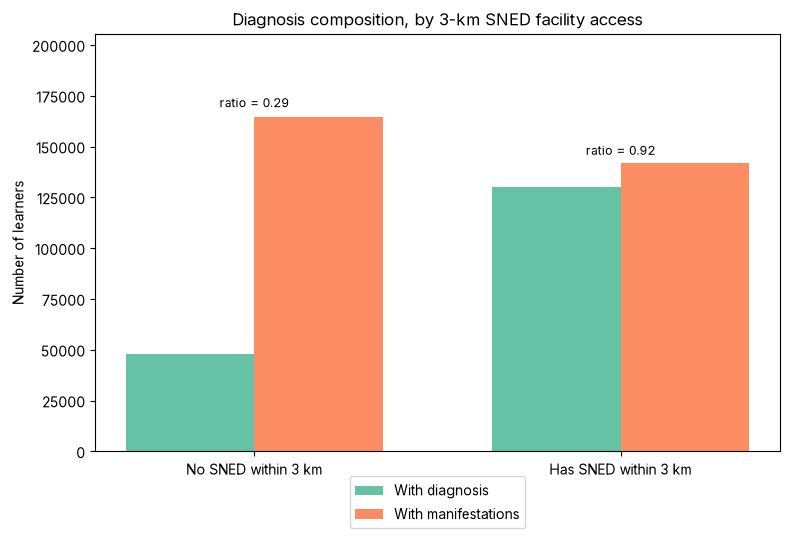

In [34]:
fig, ax = plt.subplots(figsize=(8, 5.5))
x = np.arange(2)
width = 0.35
ax.bar(x - width/2, ratio_pub.n_diagnosed.values, width, label="With diagnosis", color=PASTEL[0])
ax.bar(x + width/2, ratio_pub.n_manifestation.values, width, label="With manifestations", color=PASTEL[1])
ax.set_xticks(x)
ax.set_xticklabels(["No SNED within 3 km", "Has SNED within 3 km"])
ax.set_ylabel("Number of learners")
ax.set_title("Diagnosis composition, by 3-km SNED facility access")
for i, (d, m) in enumerate(zip(ratio_pub.n_diagnosed, ratio_pub.n_manifestation)):
    ax.text(i, max(d, m)*1.03, f"ratio = {d/m:.2f}" if m > 0 else "n/a", ha="center", fontsize=9)
ax.set_ylim(top=max(ratio_pub.n_diagnosed.max(), ratio_pub.n_manifestation.max()) * 1.25)
ax.legend(bbox_to_anchor=(0.5, -0.2), loc="lower center")
plt.tight_layout()
plt.show()

In [34]:
# Network structure: redundant vs isolated facility catchments
def build_cluster_table(pairs_df, facility_roster):
    """Bipartite facility<->school graph from an access-pairs table. Returns the graph,
    a per-cluster size table, and a node -> cluster_id lookup."""
    G = nx.Graph()
    G.add_nodes_from(facility_roster.school_id, is_facility=True)  # every facility gets a
                                                                     # node even if it has zero satellites
    non_self = pairs_df[pairs_df.facility_school_id != pairs_df.population_school_id]
    G.add_edges_from(zip(non_self.facility_school_id, non_self.population_school_id))

    components = list(nx.connected_components(G))
    facility_ids = set(facility_roster.school_id)
    rows, cluster_id_map = [], {}
    for i, comp in enumerate(components):
        facs_in_comp = comp & facility_ids
        for node in comp:
            cluster_id_map[node] = i
        rows.append({"cluster_id": i, "n_facilities": len(facs_in_comp), "n_schools_total": len(comp)})
    cluster_sizes = pd.DataFrame(rows)
    return G, cluster_sizes, cluster_id_map

# Exclude facilities with unroutable coordinates (zero rows in pp_pairs -- the same 11
# facilities already flagged earlier via roster.coord_status)
roster["is_routable"] = roster.school_id.isin(pp_pairs.facility_school_id)
routable_roster = roster[roster.is_routable].copy()
n_unroutable = (~roster.is_routable).sum()

G_pp, cluster_sizes_pp, cluster_id_map_pp = build_cluster_table(pp_pairs, routable_roster)

roster["cluster_id"] = roster.school_id.map(cluster_id_map_pp)
roster = roster.merge(cluster_sizes_pp, on="cluster_id", how="left")
roster["is_singleton_cluster"] = roster.n_facilities == 1

n_singleton = roster.loc[roster.is_routable, "is_singleton_cluster"].sum()
n_multi = (~roster.loc[roster.is_routable, "is_singleton_cluster"]).sum()
n_routable = roster.is_routable.sum()
print(f"Total clusters: {cluster_sizes_pp.shape[0]}")
print(f"Facilities in singleton clusters (no shared catchment with any other facility): "
      f"{n_singleton} of {n_routable} ({n_singleton/n_routable:.1%}) "
      f"[{n_unroutable} facilities excluded -- unroutable coordinates, see roster.coord_status]")
print(f"Facilities in multi-facility (redundant/shared-catchment) clusters: "
      f"{n_multi} of {n_routable} ({n_multi/n_routable:.1%})")

largest = cluster_sizes_pp.sort_values("n_facilities", ascending=False).iloc[0]
largest_region_mix = roster[roster.cluster_id == largest.cluster_id].psgc_region_name.value_counts()
print(f"\nLargest cluster: {int(largest.n_facilities)} facilities, {int(largest.n_schools_total)} total schools")
print("Region mix of its facilities (illustrates that shared catchment ignores region boundaries too):")
print(largest_region_mix)

Total clusters: 1685
Facilities in singleton clusters (no shared catchment with any other facility): 1390 of 2618 (53.1%) [11 facilities excluded -- unroutable coordinates, see roster.coord_status]
Facilities in multi-facility (redundant/shared-catchment) clusters: 1228 of 2618 (46.9%)

Largest cluster: 210 facilities, 2421 total schools
Region mix of its facilities (illustrates that shared catchment ignores region boundaries too):
psgc_region_name
National Capital Region (NCR)    146
Region IV-A (CALABARZON)          45
Region III (Central Luzon)        18
Name: count, dtype: int64


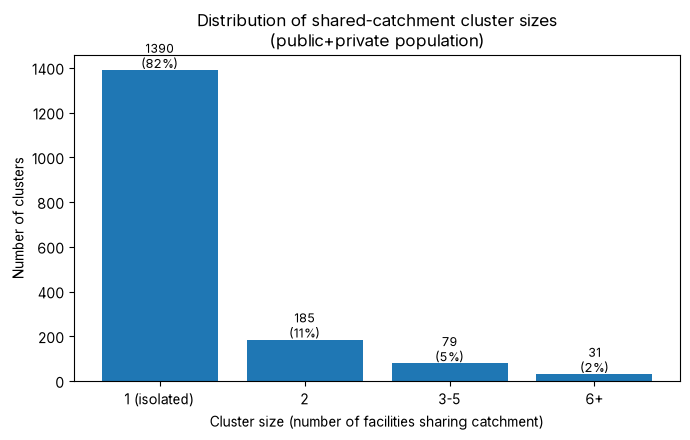

In [36]:
clus_bins = [-0.5, 1.5, 2.5, 5.5, np.inf]
clus_labels = ["1 (isolated)", "2", "3-5", "6+"]
cluster_sizes_pp["bucket"] = pd.cut(cluster_sizes_pp.n_facilities, bins=clus_bins, labels=clus_labels)
clus_bucket_counts = cluster_sizes_pp.bucket.value_counts().reindex(clus_labels)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(clus_bucket_counts.index.astype(str), clus_bucket_counts.values)
ax.set_xlabel("Cluster size (number of facilities sharing catchment)")
ax.set_ylabel("Number of clusters")
ax.set_title("Distribution of shared-catchment cluster sizes\n(public+private population)")
for i, v in enumerate(clus_bucket_counts.values):
    ax.text(i, v + 10, f"{v}\n({v/len(cluster_sizes_pp):.0%})", ha="center", fontsize=9)
plt.tight_layout()
# plt.savefig(_ROOT / "figures" / "cluster_size_distribution.png", dpi=200, bbox_inches="tight")
plt.show()



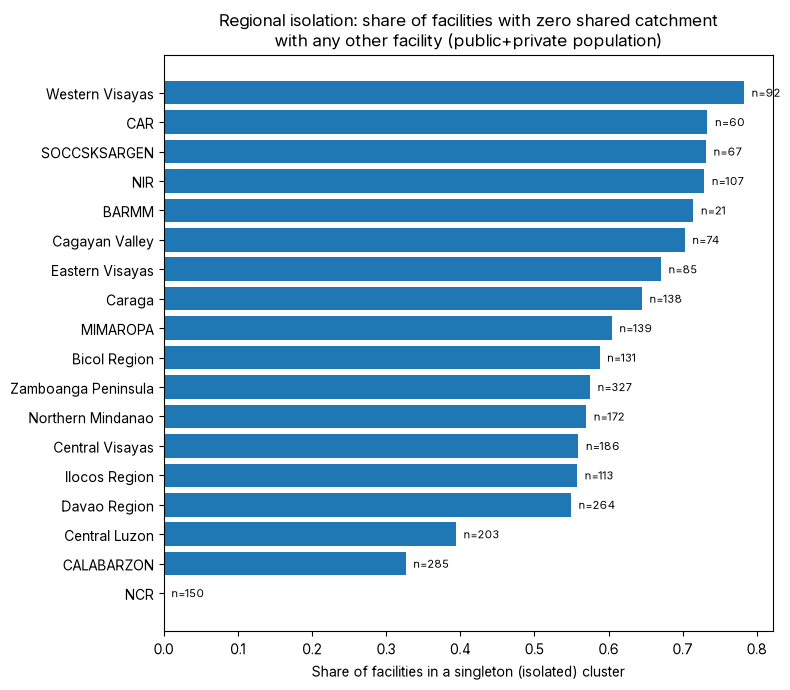

,region_short,n_facilities,n_singleton,pct_singleton
8,Western Visayas,92,72,0.782609
2,CAR,60,44,0.733333
15,SOCCSKSARGEN,67,49,0.731343
9,NIR,107,78,0.728972
17,BARMM,21,15,0.714286
1,Cagayan Valley,74,52,0.702703
11,Eastern Visayas,85,57,0.670588
16,Caraga,138,89,0.644928
6,MIMAROPA,139,84,0.604317
7,Bicol Region,131,77,0.587786


In [35]:
# Share by region
# Restrict to routable facilities, so the 11 unroutable facilities aren't counted toward each region's facility/singleton denominators.
region_singleton = add_region_short(roster[roster.is_routable], "psgc_region_name").groupby("region_short", observed=True).agg(
    n_facilities=("school_id", "count"),
    n_singleton=("is_singleton_cluster", "sum"),
).reset_index()
region_singleton["pct_singleton"] = region_singleton.n_singleton / region_singleton.n_facilities
region_singleton = region_singleton.sort_values("pct_singleton", ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(region_singleton.region_short.astype(str), region_singleton.pct_singleton)
ax.set_xlabel("Share of facilities in a singleton (isolated) cluster")
ax.set_title("Regional isolation: share of facilities with zero shared catchment\nwith any other facility (public+private population)")
ax.invert_yaxis()
for i, (v, n) in enumerate(zip(region_singleton.pct_singleton, region_singleton.n_facilities)):
    ax.text(v + 0.01, i, f"n={n}", va="center", fontsize=8)
plt.tight_layout()
# plt.savefig(_ROOT / "figures" / "singleton_share_by_region.png", dpi=200, bbox_inches="tight")
plt.show()

region_singleton




In [36]:
def load_school_coords(path):
    """public_school_coordinates has no file extension in this project -- try CSV first
    (the common case for an extensionless tabular export), fall back to parquet."""
    try:
        return pd.read_csv(path)
    except Exception:
        return pd.read_parquet(path)

public_coords_raw  = load_school_coords(DATA / "external" / "public_school_coordinates.parquet")
private_coords_raw = pd.read_parquet(DATA / "external" / "private_school_coordinates.parquet")

coords = pd.concat([
    public_coords_raw[["school_id", "latitude", "longitude", "coord_status"]],
    private_coords_raw[["school_id", "latitude", "longitude", "coord_status"]],
], ignore_index=True)

# Keep only schools with a QA-confirmed coordinate
coords = coords[coords.coord_status == "valid"]
coords = coords.drop_duplicates(subset="school_id")
coords["school_id"] = coords["school_id"].astype("int64")
coords = coords.rename(columns={"latitude": "lat", "longitude": "lon"}).set_index("school_id")[["lon", "lat"]]

# Facility roster's own coordinates take priority; the combined public+private file fills in everyone else 
roster_coords = roster.set_index("school_id")[["latitude", "longitude"]].rename(columns={"latitude": "lat", "longitude": "lon"})
combined_coords = roster_coords.combine_first(coords)

# Keep the PH bounding-box filter as a defensive safety net -- coord_status=="valid"
PH_BOUNDS = dict(lat=(4.0, 21.5), lon=(116.0, 127.5))
valid_coords = combined_coords[
    combined_coords.lat.between(*PH_BOUNDS["lat"]) & combined_coords.lon.between(*PH_BOUNDS["lon"])
]
print(f"Coordinate coverage: {len(valid_coords):,} schools with usable coordinates "
      f"({len(combined_coords) - len(valid_coords)} dropped by the bounding-box filter, "
      f"on top of whatever coord_status != 'valid' already excluded)")

Coordinate coverage: 54,139 schools with usable coordinates (1 dropped by the bounding-box filter, on top of whatever coord_status != 'valid' already excluded)


In [37]:
def get_dissolved_boundary(adm3_value, brgy_gdf, adm_col="adm3_en", dissolve=True):
    """Exact-match filter on an adm3_en value, then dissolve into a single unified
    outline -- for NCR/Metro Manila, where plotting hundreds of individual barangay
    polygons would mostly just add clutter under an already-dense network plot.
    Pass dissolve=False to keep each matched barangay's own outline instead (used
    for the ILRC catchment plot, where the finer detail is the point)."""
    filtered = brgy_gdf[brgy_gdf[adm_col] == adm3_value]
    return filtered.dissolve() if dissolve else filtered

def get_region_boundary(region_substr, brgy_gdf):
    """Dissolve barangay polygons to municipality level, filtered to one region,
    for use as a choropleth-adjacent basemap under the cluster network plots."""
    sub = brgy_gdf[brgy_gdf["adm1_en"].str.contains(region_substr, case=False, na=False)]
    return sub.dissolve(by="adm3_psgc").reset_index()

def get_province_boundaries(provinces, brgy_gdf):
    """Dissolve barangay polygons to province level for a list of adm2_en values --
    used to give the NCR panel visual context from its immediate neighbors (Batangas,
    Cavite, Rizal, Bulacan) without touching the plot's own zoom/scale, which is set
    independently from NCR facility coordinates."""
    sub = brgy_gdf[brgy_gdf["adm2_en"].isin(provinces)]
    return sub.dissolve(by="adm2_en").reset_index()

ncr_boundary   = get_dissolved_boundary("Metro Manila", brgy)   # exact match + dissolve
barmm_boundary = get_region_boundary("BARMM", brgy)              # substring match, no dissolve

# Adjacent CALABARZON/Central Luzon provinces bordering Metro Manila
NCR_ADJACENT_PROVINCES = ["Laguna", "Cavite", "Rizal", "Bulacan"]
adjacent_boundary = get_province_boundaries(NCR_ADJACENT_PROVINCES, brgy)
ncr_context_boundary = pd.concat([ncr_boundary, adjacent_boundary], ignore_index=True)
ncr_context_boundary = gpd.GeoDataFrame(ncr_context_boundary, geometry="geometry", crs=brgy.crs)

def plot_region_clusters(region_substr, ax, title, coords, cluster_id_map, G, facility_ids, boundary_gdf=None,
                          edge_alpha=0.15, node_size_fac=18, node_size_sat=4, pad=0.15):
    """Draw every cluster touched by at least one facility in `region_substr`, using real
    coordinates as node positions. Crops the view to the 1st-99th percentile of the
    FACILITY coordinates (padded) so a single long-distance stray edge -- often a bad
    geocode -- doesn't compress the area of actual interest into a corner."""
    region_facilities = roster[roster.psgc_region_name.str.contains(region_substr)].school_id
    cluster_ids = set(cluster_id_map.get(fid) for fid in region_facilities if fid in cluster_id_map)
    all_nodes = set()
    for cid in cluster_ids:
        all_nodes |= {n for n, c in cluster_id_map.items() if c == cid}
    sub = G.subgraph(all_nodes)

    if boundary_gdf is not None:
        boundary_gdf.plot(ax=ax, facecolor="#d2d2d2", edgecolor="white", linewidth=0.8, zorder=0)

    region_facilities = roster[roster.psgc_region_name.str.contains(region_substr)].school_id

    for u, v in sub.edges():
        if u in coords.index and v in coords.index:
            ax.plot([coords.loc[u, "lon"], coords.loc[v, "lon"]],
                     [coords.loc[u, "lat"], coords.loc[v, "lat"]],
                     color="gray", alpha=edge_alpha, linewidth=0.5, zorder=1)

    fac_nodes = [n for n in all_nodes if n in facility_ids and n in coords.index]
    sat_nodes = [n for n in all_nodes if n not in facility_ids and n in coords.index]
    ax.scatter(coords.loc[sat_nodes, "lon"], coords.loc[sat_nodes, "lat"],
               s=node_size_sat, color="#4C72B0", alpha=0.6, zorder=2, label="Satellite school")
    ax.scatter(coords.loc[fac_nodes, "lon"], coords.loc[fac_nodes, "lat"],
               s=node_size_fac, color="#C44E52", zorder=3, label="Facility (ILRC/SPED/SNED)")

    fx, fy = coords.loc[fac_nodes, "lon"], coords.loc[fac_nodes, "lat"]
    xlo, xhi = np.percentile(fx, [1, 99]); ylo, yhi = np.percentile(fy, [1, 99])
    xpad, ypad = (xhi - xlo) * pad + 0.05, (yhi - ylo) * pad + 0.05
    ax.set_xlim(xlo - xpad, xhi + xpad); ax.set_ylim(ylo - ypad, yhi + ypad)

    ax.set_title(f"{title}\n({len(fac_nodes)} facilities, {len(sat_nodes)} satellites)")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_aspect("equal")

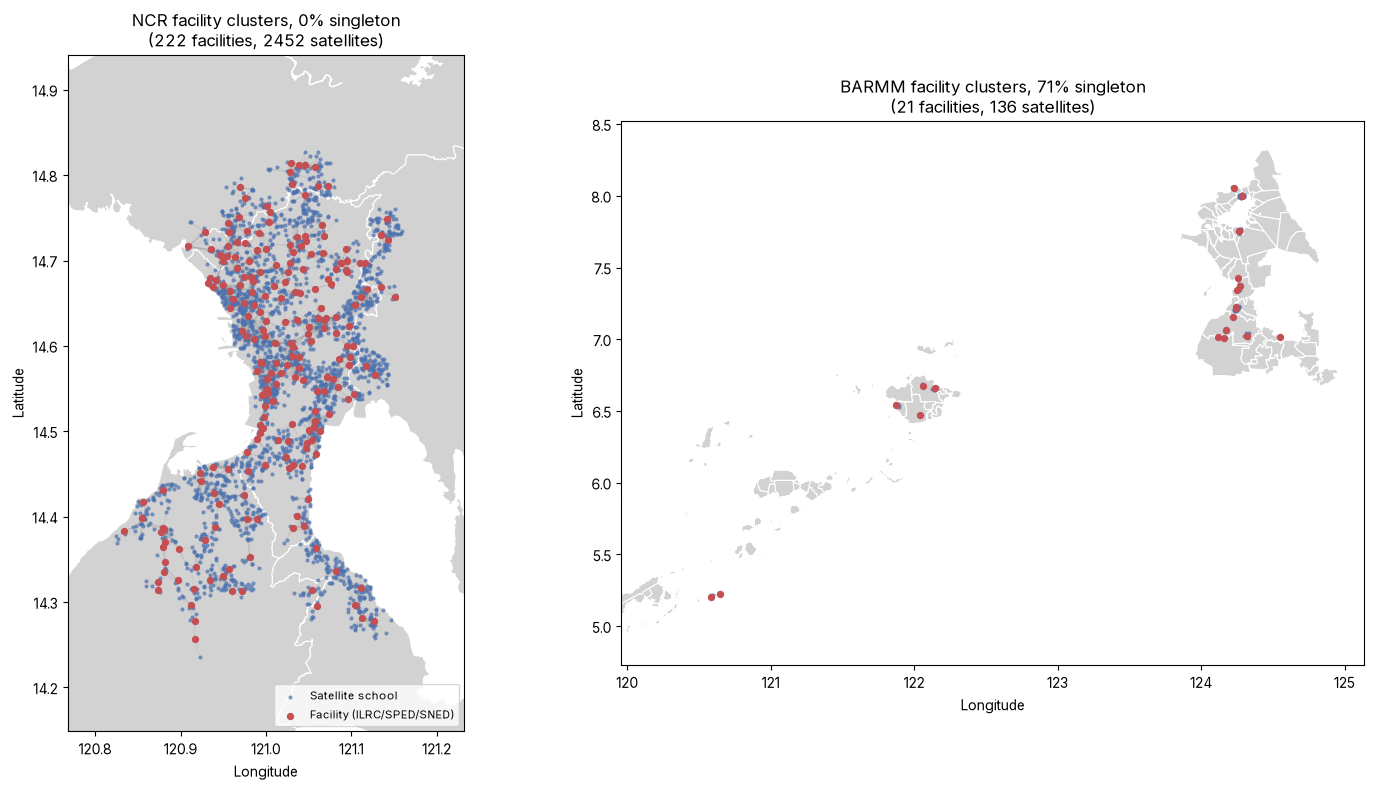

In [38]:
def pct_singleton_for(region_label):
    return region_singleton.set_index("region_short").loc[region_label, "pct_singleton"]

facility_ids = set(roster.school_id)
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
plot_region_clusters("NCR", axes[0], f"NCR facility clusters, {pct_singleton_for('NCR'):.0%} singleton",
                      valid_coords, cluster_id_map_pp, G_pp, facility_ids, boundary_gdf=ncr_context_boundary)
plot_region_clusters("BARMM", axes[1], f"BARMM facility clusters, {pct_singleton_for('BARMM'):.0%} singleton",
                      valid_coords, cluster_id_map_pp, G_pp, facility_ids, boundary_gdf=barmm_boundary)
axes[0].legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

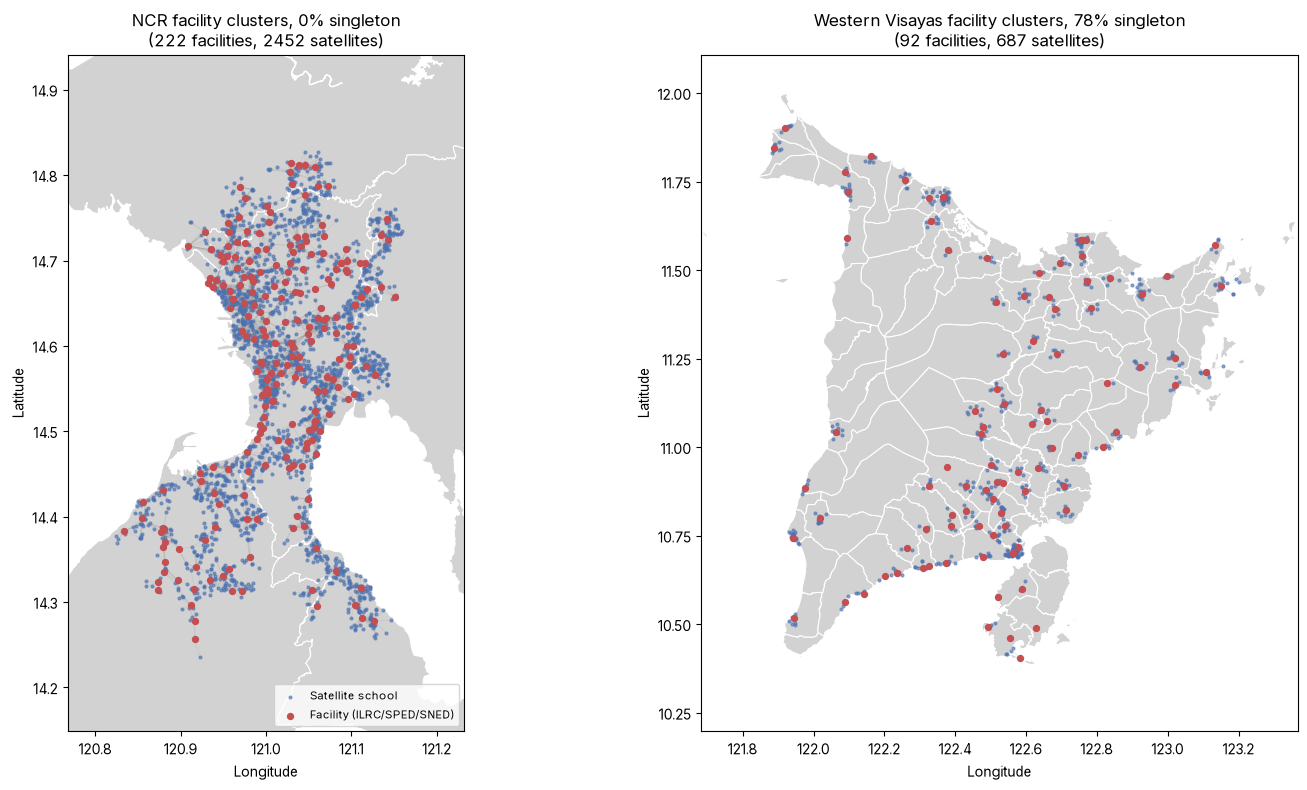

In [39]:
wvis_boundary = get_region_boundary("Western Visayas", brgy)
facility_ids = set(roster.school_id)
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
plot_region_clusters("NCR", axes[0], f"NCR facility clusters, {pct_singleton_for('NCR'):.0%} singleton",
                      valid_coords, cluster_id_map_pp, G_pp, facility_ids, boundary_gdf=ncr_context_boundary)
plot_region_clusters("Western Visayas", axes[1], f"Western Visayas facility clusters, {pct_singleton_for('Western Visayas'):.0%} singleton",
                      valid_coords, cluster_id_map_pp, G_pp, facility_ids, boundary_gdf=wvis_boundary)
axes[0].legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

In [40]:
# ILRC-specific catchment analysis
ilrc_roster = roster[roster.is_ilrc].copy()
ilrc_pairs  = pp_pairs[pp_pairs.facility_is_ilrc].copy()

G_ilrc, cluster_sizes_ilrc, cluster_id_map_ilrc = build_cluster_table(ilrc_pairs, ilrc_roster)

n_singleton_ilrc = (cluster_sizes_ilrc.n_facilities == 1).sum()
print(f"ILRC clusters: {len(cluster_sizes_ilrc)} total")
print(f"Singleton ILRC clusters: {n_singleton_ilrc} of {len(cluster_sizes_ilrc)} "
      f"({n_singleton_ilrc/len(cluster_sizes_ilrc):.1%})")
print("-> Not one ILRC shares catchment with another ILRC anywhere in the country. Unlike the "
      "full facility network, there is no multi-facility case to contrast against here -- every "
      "ILRC cluster consists of exactly one ILRC and its own satellites.")
print()

ilrc_regions_present = set(ilrc_roster.psgc_region_name.unique())
all_regions = set(roster.psgc_region_name.unique())
regions_with_zero_ilrc = all_regions - ilrc_regions_present
print(f"Regions with ZERO ILRCs at all: {regions_with_zero_ilrc}")



ILRC clusters: 57 total
Singleton ILRC clusters: 57 of 57 (100.0%)
-> Not one ILRC shares catchment with another ILRC anywhere in the country. Unlike the full facility network, there is no multi-facility case to contrast against here -- every ILRC cluster consists of exactly one ILRC and its own satellites.

Regions with ZERO ILRCs at all: {'Bangsamoro Autonomous Region In Muslim Mindanao (BARMM)', nan}


In [41]:
is_host_ilrc = ilrc_pairs.facility_school_id == ilrc_pairs.population_school_id
ilrc_sat_counts = ilrc_pairs[~is_host_ilrc].groupby("facility_school_id")["population_school_id"].nunique()

ilrc_catchment = ilrc_roster[["school_id", "school_name", "psgc_region_name", "psgc_municity_name"]].copy()
ilrc_catchment["n_satellite_schools"] = ilrc_catchment.school_id.map(ilrc_sat_counts).fillna(0).astype(int)

print(f"ILRC catchment size: mean={ilrc_catchment.n_satellite_schools.mean():.1f}, "
      f"median={ilrc_catchment.n_satellite_schools.median():.0f}, "
      f"min={ilrc_catchment.n_satellite_schools.min()}, max={ilrc_catchment.n_satellite_schools.max()}")
print("(Unlike the full facility population, every single ILRC reaches at least one satellite "
      "school -- none are fully isolated with zero nearby schools, likely because ILRCs tend to "
      "be sited in larger division/city-center schools rather than small rural annexes.)")
print()

ilrc_region_summary = ilrc_catchment.groupby("psgc_region_name").n_satellite_schools.agg(
    n_ilrcs="count", mean_catchment="mean", total_satellites="sum"
).sort_values("total_satellites", ascending=False)
ilrc_region_summary

ILRC catchment size: mean=18.0, median=12, min=2, max=61
(Unlike the full facility population, every single ILRC reaches at least one satellite school -- none are fully isolated with zero nearby schools, likely because ILRCs tend to be sited in larger division/city-center schools rather than small rural annexes.)



,n_ilrcs,mean_catchment,total_satellites
psgc_region_name,,,
National Capital Region (NCR),4,41.000000,164
Region IX (Zamboanga Peninsula),3,34.333333,103
Region IV-A (CALABARZON),4,23.500000,94
Region V (Bicol Region),4,20.000000,80
Region III (Central Luzon),3,26.333333,79
Cordillera Administrative Region (CAR),3,22.333333,67
Region X (Northern Mindanao),3,22.000000,66
Region XII (SOCCSKSARGEN),4,15.750000,63
Region XI (Davao Region),5,12.200000,61


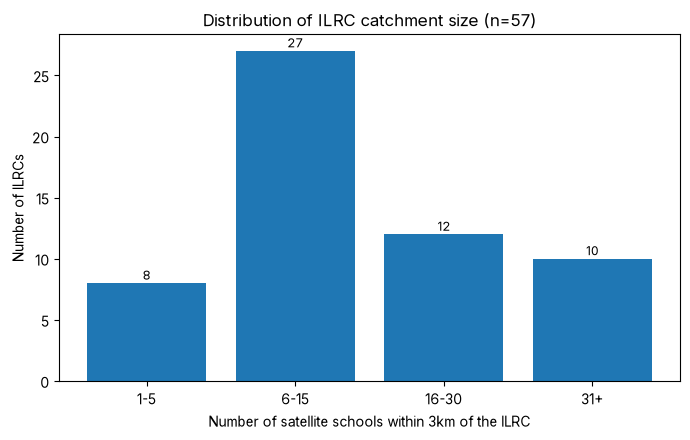

In [42]:
ilrc_bins = [-0.5, 5.5, 15.5, 30.5, np.inf]
ilrc_labels = ["1-5", "6-15", "16-30", "31+"]
ilrc_catchment["bucket"] = pd.cut(ilrc_catchment.n_satellite_schools, bins=ilrc_bins, labels=ilrc_labels)
ilrc_bucket_counts = ilrc_catchment.bucket.value_counts().reindex(ilrc_labels)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(ilrc_bucket_counts.index.astype(str), ilrc_bucket_counts.values)
ax.set_xlabel("Number of satellite schools within 3km of the ILRC")
ax.set_ylabel("Number of ILRCs")
ax.set_title("Distribution of ILRC catchment size (n=57)")
for i, v in enumerate(ilrc_bucket_counts.values):
    ax.text(i, v + 0.3, f"{v}", ha="center", fontsize=9)
plt.tight_layout()
# plt.savefig(_ROOT / "figures" / "ilrc_catchment_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

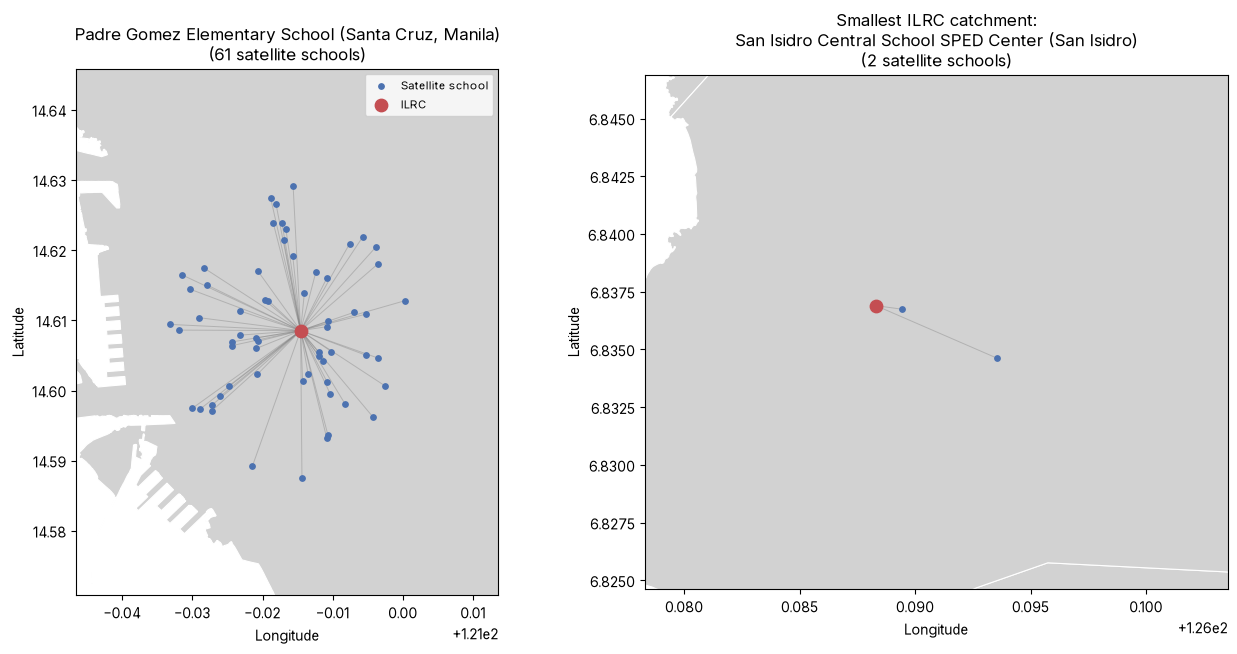

In [43]:
def get_facility_boundary(facility_row, brgy_gdf, ncr_boundary=None):
    muni_code = None
    if pd.notna(facility_row.psgc_municity):
        muni_code = str(int(facility_row.psgc_municity)).zfill(10)
    if muni_code and (brgy_gdf.adm3_psgc == muni_code).any():
        return get_dissolved_boundary(muni_code, brgy_gdf, adm_col="adm3_psgc", dissolve=False)

    muni_name, prov_name = facility_row.psgc_municity_name, facility_row.psgc_province_name
    if pd.notna(muni_name) and pd.notna(prov_name):
        name_prov_match = brgy_gdf[(brgy_gdf.adm3_en == muni_name) & (brgy_gdf.adm2_en == prov_name)]
        if len(name_prov_match):
            return name_prov_match

    if ncr_boundary is not None and "National Capital Region" in str(facility_row.psgc_region_name):
        return ncr_boundary

    if pd.notna(prov_name) and (brgy_gdf.adm2_en == prov_name).any():
        return get_province_boundaries([prov_name], brgy_gdf)

    return None

def plot_single_facility_catchment(facility_id, pairs_df, coords, ax, title, pad=0.4, bound_deg=0.15, boundary_gdf=None):
    if boundary_gdf is not None:
        boundary_gdf.plot(ax=ax, facecolor="#d2d2d2", edgecolor="white", linewidth=0.8, zorder=0)

    rows = pairs_df[(pairs_df.facility_school_id == facility_id) &
                     (pairs_df.facility_school_id != pairs_df.population_school_id)]
    sat_ids = rows.population_school_id.tolist()
    fx, fy = coords.loc[facility_id, "lon"], coords.loc[facility_id, "lat"]
    valid_sat = [s for s in sat_ids if s in coords.index]

    for sid in valid_sat:
        ax.plot([fx, coords.loc[sid, "lon"]], [fy, coords.loc[sid, "lat"]],
                 color="gray", alpha=0.4, linewidth=0.7, zorder=1)
    ax.scatter(coords.loc[valid_sat, "lon"], coords.loc[valid_sat, "lat"],
               s=15, color="#4C72B0", zorder=2, label="Satellite school")
    ax.scatter([fx], [fy], s=80, color="#C44E52", zorder=3, label="ILRC")

    near = [s for s in valid_sat if abs(coords.loc[s, "lon"] - fx) < bound_deg
                                  and abs(coords.loc[s, "lat"] - fy) < bound_deg]
    allx = np.array([fx] + coords.loc[near, "lon"].tolist())
    ally = np.array([fy] + coords.loc[near, "lat"].tolist())
    xlo, xhi, ylo, yhi = allx.min(), allx.max(), ally.min(), ally.max()
    xpad, ypad = max((xhi - xlo) * pad, 0.01), max((yhi - ylo) * pad, 0.01)
    ax.set_xlim(xlo - xpad, xhi + xpad); ax.set_ylim(ylo - ypad, yhi + ypad)

    n_far = len(valid_sat) - len(near)
    subtitle = f"({len(sat_ids)} satellite schools" + (f", {n_far} far outlier(s) not shown in frame)" if n_far else ")")
    ax.set_title(f"{title}\n{subtitle}")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_aspect("equal")

largest_ilrc = ilrc_catchment.sort_values("n_satellite_schools", ascending=False).iloc[0]
smallest_ilrc = ilrc_catchment.sort_values("n_satellite_schools", ascending=True).iloc[0]

# ilrc_catchment only carries school_id/school_name/psgc_region_name/psgc_municity_name
largest_row  = ilrc_roster.set_index("school_id").loc[largest_ilrc.school_id]
smallest_row = ilrc_roster.set_index("school_id").loc[smallest_ilrc.school_id]
largest_boundary  = get_facility_boundary(largest_row,  brgy, ncr_boundary=ncr_boundary)
smallest_boundary = get_facility_boundary(smallest_row, brgy, ncr_boundary=ncr_boundary)

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
plot_single_facility_catchment(
    largest_ilrc.school_id, ilrc_pairs, valid_coords, axes[0],
    f"{largest_ilrc.school_name} ({largest_ilrc.psgc_municity_name}, Manila)",
    boundary_gdf=largest_boundary
)
plot_single_facility_catchment(
    smallest_ilrc.school_id, ilrc_pairs, valid_coords, axes[1],
    f"Smallest ILRC catchment:\n{smallest_ilrc.school_name} ({smallest_ilrc.psgc_municity_name})",
    boundary_gdf=smallest_boundary
)
axes[0].legend(loc="best", fontsize=8)
plt.tight_layout()
# plt.savefig(_ROOT / "figures" / "ilrc_largest_vs_smallest.png", dpi=200, bbox_inches="tight")
plt.show()

### **E. Host vs. Satellite Learner and Disability Profiles**

In [44]:
# Host-school vs. satellite-school learner load per facility
def build_facility_load(pairs_df, school_totals):
    """For each facility, split its within-3km population into the host school itself
    (population_school_id == facility_school_id, distance 0) vs. every other satellite
    school, then attach learner totals to both sides."""
    m = pairs_df.merge(
        school_totals, left_on="population_school_id", right_on="beis_school_id", how="left"
    )
    for c in ["n_diagnosed", "n_manifestation", "total_learners"]:
        m[c] = m[c].fillna(0)

    is_host = m.facility_school_id == m.population_school_id

    host = m[is_host].groupby("facility_school_id", as_index=False).agg(
        host_total=("total_learners", "sum"),
        host_diagnosed=("n_diagnosed", "sum"),
        host_manif=("n_manifestation", "sum"),
    )
    sat = m[~is_host].groupby("facility_school_id", as_index=False).agg(
        satellite_total=("total_learners", "sum"),
        satellite_diagnosed=("n_diagnosed", "sum"),
        satellite_manif=("n_manifestation", "sum"),
        n_satellite_schools=("population_school_id", "nunique"),
    )
    load = host.merge(sat, on="facility_school_id", how="outer").fillna(0)
    load["host_share"] = load.host_total / (load.host_total + load.satellite_total).replace(0, np.nan)

    fac_names = pairs_df[["facility_school_id", "facility_school_name",
                           "facility_is_ilrc", "facility_is_sned", "facility_is_sped_center"]].drop_duplicates()
    return fac_names.merge(load, on="facility_school_id", how="left")

facility_load_pub = build_facility_load(pub_pairs, school_totals)
facility_load_pp  = build_facility_load(pp_pairs, school_totals)

print(f"Facilities with NO host-school row at all (likely invalid/suspect coordinates — "
      f"see roster.coord_status): "
      f"{roster.school_id[~roster.school_id.isin(pub_pairs.facility_school_id)].nunique()}")

facility_load_pp.sort_values("satellite_total", ascending=False).head(10)

Facilities with NO host-school row at all (likely invalid/suspect coordinates — see roster.coord_status): 11


,facility_school_id,facility_school_name,facility_is_ilrc,facility_is_sned,facility_is_sped_center,host_total,host_diagnosed,host_manif,satellite_total,satellite_diagnosed,satellite_manif,n_satellite_schools,host_share
2485,500333,Eulogio Rodriguez Integrated School,False,True,False,242.0,212.0,30.0,3799.0,2163.0,1636.0,67.0,0.059886
2275,136669,Nueve de Febrero Elementary School,False,True,False,181.0,174.0,7.0,3379.0,1926.0,1453.0,62.0,0.050843
2276,136670,Pedro P. Cruz (Mauway) ES,False,True,False,207.0,174.0,33.0,3374.0,1889.0,1485.0,60.0,0.057805
2606,502655,Kabayanan Integrated School,False,False,True,131.0,87.0,44.0,3027.0,1510.0,1517.0,58.0,0.041482
2484,500331,Isaac Lopez Integrated School (Isaac Lopez ES),False,False,True,299.0,228.0,71.0,2967.0,1803.0,1164.0,55.0,0.091549
1928,129695,Elpidio Quirino ES,False,True,False,44.0,18.0,26.0,2407.0,1104.0,1303.0,56.0,0.017952
1931,129698,J.P. Laurel ES,False,True,False,19.0,12.0,7.0,2382.0,999.0,1383.0,57.0,0.007913
2269,136600,Padre Zamora Elementary School,False,True,False,74.0,65.0,9.0,2299.0,1715.0,584.0,60.0,0.031184
1936,129706,Manuel L. Quezon ES,False,True,False,56.0,30.0,26.0,2251.0,947.0,1304.0,50.0,0.024274
1937,129708,STA. ANA CENTRAL ELEM. SCHOOL,False,True,False,146.0,78.0,68.0,2160.0,899.0,1261.0,50.0,0.063313


In [45]:
# Satellite vs host school enr comparison
def build_host_satellite_comparison(load_df):
    df = load_df[(load_df.host_total > 0) | (load_df.satellite_total > 0)].copy()
    df["mean_satellite_school_size"] = df.satellite_total / df.n_satellite_schools.replace(0, np.nan)
    return df[[
        "facility_school_id", "facility_school_name",
        "host_total", "host_diagnosed", "host_manif",
        "satellite_total", "satellite_diagnosed", "satellite_manif",
        "n_satellite_schools", "mean_satellite_school_size", "host_share",
    ]]

host_sat_comparison_pp  = build_host_satellite_comparison(facility_load_pp)
host_sat_comparison_pub = build_host_satellite_comparison(facility_load_pub)

# Paired test: is a host school's own enrollment systematically different from the TYPICAL (mean) satellite school's enrollment nearby?
paired_pp = host_sat_comparison_pp.dropna(subset=["mean_satellite_school_size"])
stat_pp, p_pp = wilcoxon(paired_pp.host_total, paired_pp.mean_satellite_school_size)

paired_pub = host_sat_comparison_pub.dropna(subset=["mean_satellite_school_size"])
stat_pub, p_pub = wilcoxon(paired_pub.host_total, paired_pub.mean_satellite_school_size)

for label, paired, stat, p_val in [("Public+private", paired_pp, stat_pp, p_pp),
                                     ("Public-only", paired_pub, stat_pub, p_pub)]:
    direction = "LARGER" if paired.host_total.median() > paired.mean_satellite_school_size.median() else "SMALLER"
    print(f"--- {label} population ---")
    print(f"Wilcoxon signed-rank (host_total vs. mean satellite school size): "
          f"n={len(paired)}, stat={stat:.1f}, p={p_val:.4g}")
    print(f"Median host_total = {paired.host_total.median():.1f}, "
          f"Median mean_satellite_school_size = {paired.mean_satellite_school_size.median():.1f}")
    print(f"Host schools are, on the whole, {direction} than a typical nearby satellite school.")
    print()

host_sat_comparison_pp.sort_values("host_total", ascending=False).head(10)

--- Public+private population ---
Wilcoxon signed-rank (host_total vs. mean satellite school size): n=2416, stat=156384.0, p=0
Median host_total = 36.0, Median mean_satellite_school_size = 7.5
Host schools are, on the whole, LARGER than a typical nearby satellite school.

--- Public-only population ---
Wilcoxon signed-rank (host_total vs. mean satellite school size): n=2404, stat=276880.0, p=1.597e-253
Median host_total = 37.0, Median mean_satellite_school_size = 9.3
Host schools are, on the whole, LARGER than a typical nearby satellite school.



,facility_school_id,facility_school_name,host_total,host_diagnosed,host_manif,satellite_total,satellite_diagnosed,satellite_manif,n_satellite_schools,mean_satellite_school_size,host_share
2481,500302,General Santos City SPED Integrated School,797.0,612.0,185.0,212.0,52.0,160.0,14.0,15.142857,0.789891
2214,136432,J. P. Rizal Elementary School,705.0,657.0,48.0,1206.0,946.0,260.0,83.0,14.530120,0.368917
2483,500329,Philippine School for the Deaf,606.0,600.0,6.0,1737.0,1129.0,608.0,59.0,29.440678,0.258643
1944,129717,Davao City Special School,528.0,491.0,37.0,1390.0,561.0,829.0,29.0,47.931034,0.275287
964,117480,BACOLOD CITY SPED CENTER,501.0,473.0,28.0,751.0,433.0,318.0,41.0,18.317073,0.400160
2274,136639,Bagong Silang Elementary School,498.0,425.0,73.0,836.0,507.0,329.0,48.0,17.416667,0.373313
330,107195,San Fernando Elementary School,490.0,439.0,51.0,215.0,186.0,29.0,29.0,7.413793,0.695035
2216,136452,Padre Gomez Elementary School,451.0,436.0,15.0,1470.0,1308.0,162.0,61.0,24.098361,0.234774
2492,500392,Antipolo City SPED Center,451.0,398.0,53.0,552.0,355.0,197.0,47.0,11.744681,0.449651
2519,500983,San Fernando City SPED Integrated School,440.0,302.0,138.0,393.0,128.0,265.0,18.0,21.833333,0.528211


In [46]:
# Category-level host/satellite breakdown
def build_facility_category_load(pairs_df, school_disability_long):
    m = pairs_df.merge(
        school_disability_long, left_on="population_school_id", right_on="beis_school_id", how="left"
    )
    m["n_learners"] = m["n_learners"].fillna(0)
    is_host = m.facility_school_id == m.population_school_id
    m["side"] = np.where(is_host, "host", "satellite")
    return m.groupby(["facility_school_id", "side", "Diagnosis_Type", "Category"], as_index=False)["n_learners"].sum()

facility_category_load_pub = build_facility_category_load(pub_pairs, school_disability_long)
facility_category_load_pub.head()



,facility_school_id,side,Diagnosis_Type,Category,n_learners
0,100010,host,With Diagnosis from Licensed Medical Specialist,Autism Spectrum Disorder,18.0
1,100010,host,With Diagnosis from Licensed Medical Specialist,Emotional-Behavioral Disorder,1.0
2,100010,host,With Diagnosis from Licensed Medical Specialist,Hearing Impairment,4.0
3,100010,host,With Diagnosis from Licensed Medical Specialist,Intellectual Disability,15.0
4,100010,host,With Diagnosis from Licensed Medical Specialist,Learning Disability,2.0


In [47]:
# Host school diagnosis type skew
def host_diagnosis_skew(load_df, label):
    df = load_df[load_df.host_total > 0].copy()
    total_diag, total_manif = df.host_diagnosed.sum(), df.host_manif.sum()
    stat, p_val = wilcoxon(df.host_diagnosed, df.host_manif)
    print(f"--- {label} ---")
    print(f"Host schools nationally: {total_diag:,.0f} diagnosed vs. {total_manif:,.0f} manifestation-only "
          f"({total_diag/(total_diag+total_manif):.1%} diagnosed)")
    print(f"Wilcoxon signed-rank (paired, per facility): n={len(df)}, stat={stat:.1f}, p={p_val:.4g}")
    direction = "MORE diagnosed than manifestation" if df.host_diagnosed.median() > df.host_manif.median() else "MORE manifestation than diagnosed"
    print(f"Median host school skews: {direction} (median diagnosed={df.host_diagnosed.median():.1f}, "
          f"median manifestation={df.host_manif.median():.1f})")
    print()

host_diagnosis_skew(facility_load_pp, "Public+private population")
host_diagnosis_skew(facility_load_pub, "Public-only population")

--- Public+private population ---
Host schools nationally: 93,763 diagnosed vs. 58,812 manifestation-only (61.5% diagnosed)
Wilcoxon signed-rank (paired, per facility): n=2570, stat=1237249.0, p=2.255e-19
Median host school skews: MORE diagnosed than manifestation (median diagnosed=15.0, median manifestation=13.0)

--- Public-only population ---
Host schools nationally: 93,763 diagnosed vs. 58,812 manifestation-only (61.5% diagnosed)
Wilcoxon signed-rank (paired, per facility): n=2570, stat=1237249.0, p=2.255e-19
Median host school skews: MORE diagnosed than manifestation (median diagnosed=15.0, median manifestation=13.0)



In [48]:
# Per-facility host vs. satellite disability profile
def facility_satellite_top_category(pairs_df, school_disability_long):
    """Top disability category (by summed identified learners) among a facility's
    SATELLITE schools only (excludes the host school itself)."""
    m = pairs_df.merge(
        school_disability_long, left_on="population_school_id", right_on="beis_school_id", how="left"
    )
    m["n_learners"] = m["n_learners"].fillna(0)
    is_sat = m.facility_school_id != m.population_school_id
    sat = m[is_sat].groupby(["facility_school_id", "Diagnosis_Type", "Category"], as_index=False)["n_learners"].sum()
    top = (
        sat.sort_values("n_learners", ascending=False)
        .drop_duplicates(subset=["facility_school_id", "Diagnosis_Type"], keep="first")
    )
    wide = top.pivot(index="facility_school_id", columns="Diagnosis_Type", values=["Category", "n_learners"])
    wide.columns = ["_".join(c) for c in wide.columns]
    wide = wide.rename(columns={
        "Category_With Diagnosis from Licensed Medical Specialist": "satellite_top_diagnosed_category",
        "Category_With Manifestations": "satellite_top_manifestation_category",
        "n_learners_With Diagnosis from Licensed Medical Specialist": "satellite_top_diagnosed_n",
        "n_learners_With Manifestations": "satellite_top_manifestation_n",
    }).reset_index()
    return wide

def build_facility_profile(facility_load_df, pairs_df, school_totals, school_disability_long):
    host_cols = school_totals[[
        "beis_school_id", "top_diagnosed_category", "top_diagnosed_n",
        "top_manifestation_category", "top_manifestation_n",
    ]].rename(columns={
        "top_diagnosed_category": "host_top_diagnosed_category",
        "top_diagnosed_n": "host_top_diagnosed_n",
        "top_manifestation_category": "host_top_manifestation_category",
        "top_manifestation_n": "host_top_manifestation_n",
    })
    profile = facility_load_df.merge(
        host_cols, left_on="facility_school_id", right_on="beis_school_id", how="left"
    ).drop(columns="beis_school_id")

    sat_top = facility_satellite_top_category(pairs_df, school_disability_long)
    profile = profile.merge(sat_top, on="facility_school_id", how="left")
    profile["combined_total"] = profile.host_total + profile.satellite_total

    return profile[[
        "facility_school_id", "facility_school_name", "facility_is_ilrc", "facility_is_sned", "facility_is_sped_center",
        "host_total", "host_diagnosed", "host_manif",
        "host_top_diagnosed_category", "host_top_diagnosed_n",
        "host_top_manifestation_category", "host_top_manifestation_n",
        "satellite_total", "satellite_diagnosed", "satellite_manif", "n_satellite_schools",
        "satellite_top_diagnosed_category", "satellite_top_diagnosed_n",
        "satellite_top_manifestation_category", "satellite_top_manifestation_n",
        "combined_total", "host_share",
    ]]

facility_profile_pp  = build_facility_profile(facility_load_pp,  pp_pairs,  school_totals, school_disability_long)
facility_profile_pub = build_facility_profile(facility_load_pub, pub_pairs, school_totals, school_disability_long)

print(f"Per-facility profile table built: {len(facility_profile_pp)} facilities (public+private population), "
      f"{len(facility_profile_pub)} (public-only population)")
facility_profile_pp.sort_values("combined_total", ascending=False).head(10)

Per-facility profile table built: 2618 facilities (public+private population), 2618 (public-only population)


,facility_school_id,facility_school_name,facility_is_ilrc,facility_is_sned,facility_is_sped_center,host_total,host_diagnosed,host_manif,host_top_diagnosed_category,host_top_diagnosed_n,host_top_manifestation_category,host_top_manifestation_n,satellite_total,satellite_diagnosed,satellite_manif,n_satellite_schools,satellite_top_diagnosed_category,satellite_top_diagnosed_n,satellite_top_manifestation_category,satellite_top_manifestation_n,combined_total,host_share
2485,500333,Eulogio Rodriguez Integrated School,False,True,False,242.0,212.0,30.0,Autism Spectrum Disorder,79.0,"Difficulty in Remembering, Concentrating, Payi...",11.0,3799.0,2163.0,1636.0,67.0,Autism Spectrum Disorder,1143.0,Difficulty in Seeing,739.0,4041.0,0.059886
2276,136670,Pedro P. Cruz (Mauway) ES,False,True,False,207.0,174.0,33.0,Autism Spectrum Disorder,104.0,"Difficulty in Remembering, Concentrating, Payi...",15.0,3374.0,1889.0,1485.0,60.0,Autism Spectrum Disorder,923.0,Difficulty in Seeing,662.0,3581.0,0.057805
2275,136669,Nueve de Febrero Elementary School,False,True,False,181.0,174.0,7.0,Autism Spectrum Disorder,93.0,"Difficulty in Remembering, Concentrating, Payi...",4.0,3379.0,1926.0,1453.0,62.0,Autism Spectrum Disorder,991.0,Difficulty in Seeing,612.0,3560.0,0.050843
2484,500331,Isaac Lopez Integrated School (Isaac Lopez ES),False,False,True,299.0,228.0,71.0,Autism Spectrum Disorder,154.0,Difficulty in Seeing,35.0,2967.0,1803.0,1164.0,55.0,Autism Spectrum Disorder,871.0,Difficulty in Seeing,376.0,3266.0,0.091549
2606,502655,Kabayanan Integrated School,False,False,True,131.0,87.0,44.0,Autism Spectrum Disorder,47.0,Difficulty in Seeing,38.0,3027.0,1510.0,1517.0,58.0,Autism Spectrum Disorder,621.0,Difficulty in Seeing,642.0,3158.0,0.041482
1928,129695,Elpidio Quirino ES,False,True,False,44.0,18.0,26.0,Autism Spectrum Disorder,10.0,Difficulty in Applying Knowledge,12.0,2407.0,1104.0,1303.0,56.0,Autism Spectrum Disorder,560.0,"Difficulty in Remembering, Concentrating, Payi...",532.0,2451.0,0.017952
1931,129698,J.P. Laurel ES,False,True,False,19.0,12.0,7.0,Autism Spectrum Disorder,4.0,"Difficulty in Remembering, Concentrating, Payi...",5.0,2382.0,999.0,1383.0,57.0,Autism Spectrum Disorder,493.0,"Difficulty in Remembering, Concentrating, Payi...",574.0,2401.0,0.007913
2269,136600,Padre Zamora Elementary School,False,True,False,74.0,65.0,9.0,Autism Spectrum Disorder,43.0,"Difficulty in Remembering, Concentrating, Payi...",4.0,2299.0,1715.0,584.0,60.0,Autism Spectrum Disorder,603.0,Difficulty in Seeing,206.0,2373.0,0.031184
2483,500329,Philippine School for the Deaf,False,True,False,606.0,600.0,6.0,Hearing Impairment,590.0,Difficulty in Hearing,6.0,1737.0,1129.0,608.0,59.0,Autism Spectrum Disorder,605.0,Difficulty in Seeing,208.0,2343.0,0.258643
2271,136605,P. Villanueva Elementary School,False,True,False,389.0,378.0,11.0,Autism Spectrum Disorder,229.0,"Difficulty in Remembering, Concentrating, Payi...",4.0,1942.0,1338.0,604.0,60.0,Hearing Impairment,594.0,Difficulty in Seeing,209.0,2331.0,0.166881


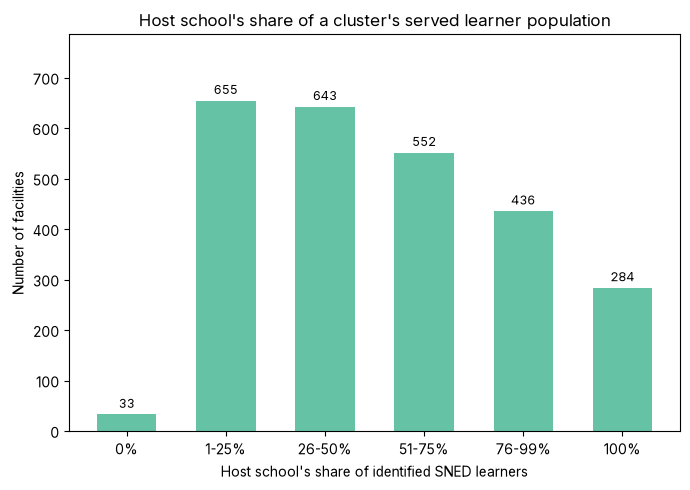

In [49]:
# Host-share distribution across facilities
# Restrict to facilities with at least one identified learner on either side
active_pp = facility_profile_pp[(facility_profile_pp.host_total > 0) | (facility_profile_pp.satellite_total > 0)]

host_share_bins = [-0.01, 0.0, 0.25, 0.5, 0.75, 0.999, 1.0]
host_share_labels = ["0%", "1-25%", "26-50%", "51-75%", "76-99%", "100%"]
host_share_bucket = pd.cut(active_pp.host_share, bins=host_share_bins, labels=host_share_labels)
host_share_bucket_counts = host_share_bucket.value_counts().reindex(host_share_labels)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(host_share_bucket_counts.index.astype(str), host_share_bucket_counts.values, color=PASTEL[0], width=0.6)
ax.set_xlabel("Host school's share of identified SNED learners")
ax.set_ylabel("Number of facilities")
ax.set_title("Host school's share of a cluster's served learner population")
plt.xticks(rotation=0)
for i, v in enumerate(host_share_bucket_counts.values):
    ax.text(i, v + host_share_bucket_counts.max() * 0.02, f"{v}", ha="center", fontsize=9)
ax.set_ylim(top=host_share_bucket_counts.max() * 1.2)
plt.tight_layout()
plt.show()

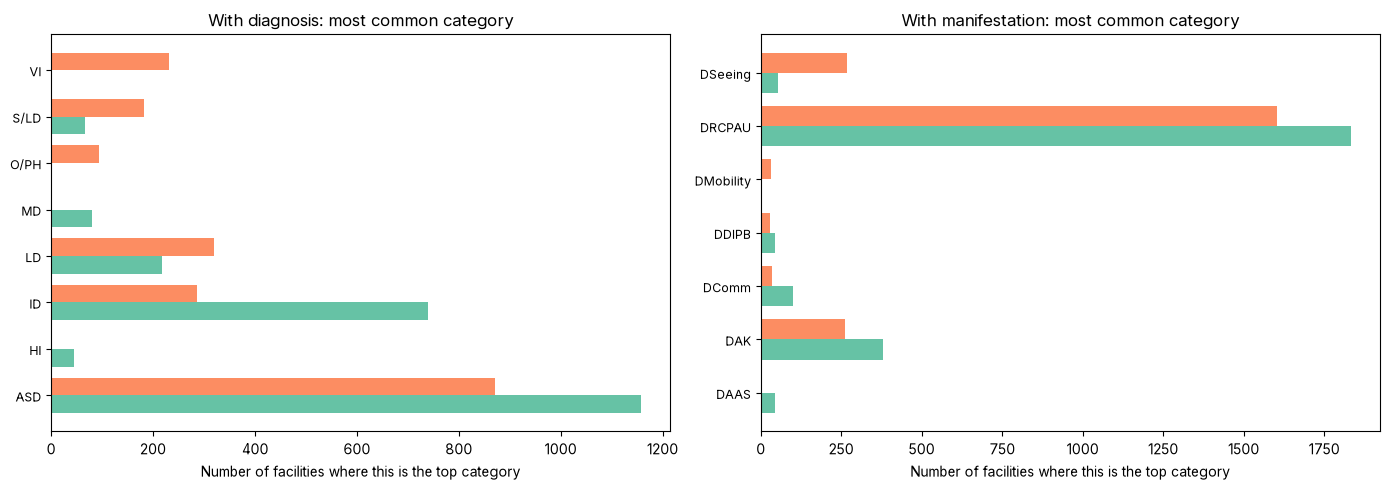

In [50]:
# Dominant disability categories
DIAGNOSED_ABBR = {
    "Visual Impairment": "VI", "Hearing Impairment": "HI", "Learning Disability": "LD",
    "Intellectual Disability": "ID", "Autism Spectrum Disorder": "ASD",
    "Orthopedic/Physical Handicap": "O/PH", "Speech/Language Disorder": "S/LD",
    "Multiple Disabilities": "MD",
    "Emotional-Behavioral Disorder": "EBD", "Cerebral Palsy": "CP",
    "Special Health Problem/Chronic Disease": "SHP/CD",
}
MANIFESTATION_ABBR = {
    "Difficulty in Seeing": "DSeeing", "Difficulty in Hearing": "DHearing",
    "Difficulty in Applying Knowledge": "DAK",
    "Difficulty in Remembering, Concentrating, Paying Attention and Understanding": "DRCPAU",
    "Difficulty in Applying Adaptive Skills": "DAAS",
    "Difficulty in Displaying Inter-Personal Behavior": "DDIPB",
    "Difficulty in Mobility (Walking, Climbing and Grasping)": "DMobility",
    "Difficulty in Communicating": "DComm",
}

def side_top_category_counts(df, col, top_n=6):
    return df[col].value_counts().head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (host_col, sat_col, label, abbr) in zip(axes, [
    ("host_top_diagnosed_category", "satellite_top_diagnosed_category", "With diagnosis", DIAGNOSED_ABBR),
    ("host_top_manifestation_category", "satellite_top_manifestation_category", "With manifestation", MANIFESTATION_ABBR),
]):
    host_counts = side_top_category_counts(active_pp, host_col)
    sat_counts = side_top_category_counts(active_pp, sat_col)
    categories = sorted(set(host_counts.index) | set(sat_counts.index))
    x = np.arange(len(categories))
    width = 0.38
    ax.barh(x - width/2, [host_counts.get(c, 0) for c in categories], height=width, label="Host school's top category", color=PASTEL[0])
    ax.barh(x + width/2, [sat_counts.get(c, 0) for c in categories], height=width, label="Satellite schools' top category", color=PASTEL[1])
    ax.set_yticks(x); ax.set_yticklabels([abbr.get(c, c) for c in categories], fontsize=9)
    ax.set_xlabel("Number of facilities where this is the top category")
    ax.set_title(f"{label}: most common category")

plt.tight_layout()
plt.show()

All-learner total across regions: 505,508 of 523,939 national (96.5% -- the remainder has no region match via pp_summary, see Section 5.2)
Regions with a negative disconnected_total: 0 (should always be 0 -- reached_total_dedup is deduplicated, unlike combined_total)


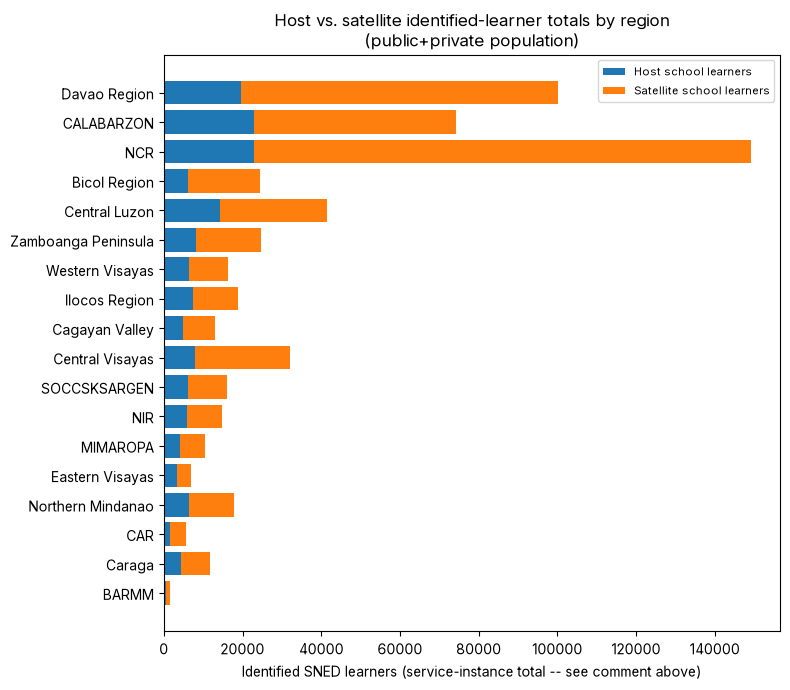

,region_short,n_facilities,host_total,satellite_total,combined_total,host_share_region,all_learners_region,reached_total_dedup,disconnected_total
14,Davao Region,264,19675.0,80371.0,100046.0,0.196660,58402.0,34084.0,24318.0
5,CALABARZON,285,22897.0,51238.0,74135.0,0.308855,55900.0,44242.0,11658.0
4,NCR,150,22794.0,126281.0,149075.0,0.152903,42874.0,41024.0,1850.0
7,Bicol Region,131,6025.0,18405.0,24430.0,0.246623,36176.0,14334.0,21842.0
3,Central Luzon,203,14314.0,27193.0,41507.0,0.344857,33829.0,24857.0,8972.0
12,Zamboanga Peninsula,327,8307.0,16336.0,24643.0,0.337094,33767.0,16361.0,17406.0
8,Western Visayas,92,6519.0,9748.0,16267.0,0.400750,32415.0,14202.0,18213.0
0,Ilocos Region,113,7409.0,11427.0,18836.0,0.393343,32200.0,15361.0,16839.0
1,Cagayan Valley,74,4872.0,8038.0,12910.0,0.377382,31426.0,9885.0,21541.0
10,Central Visayas,186,7852.0,24091.0,31943.0,0.245813,28690.0,18159.0,10531.0


In [51]:
# Region-level rollup: how much of the identified need sits in host schools vs.
# satellites, and does that split vary by region 
facility_profile_pp = facility_profile_pp.merge(
    roster[["school_id", "psgc_region_name"]], left_on="facility_school_id", right_on="school_id", how="left"
).drop(columns="school_id")

region_host_sat = add_region_short(facility_profile_pp, "psgc_region_name").groupby("region_short", observed=True).agg(
    n_facilities=("facility_school_id", "count"),
    host_total=("host_total", "sum"),
    satellite_total=("satellite_total", "sum"),
).reset_index()

# combined_total is a SERVICE-INSTANCE total, not a unique-learner total
region_host_sat["combined_total"] = region_host_sat.host_total + region_host_sat.satellite_total
region_host_sat["host_share_region"] = region_host_sat.host_total / region_host_sat.combined_total

# All identified SNED learners per region -- host, satellite, AND disconnected (not
# within 3km of any facility) -- using a school-level region+province crosswalk
# (pp_summary's population_school_id -> psgc_region_name/psgc_province_name; ~96.5% of
# national learners match a region this way
school_region_map = pp_summary[["population_school_id", "psgc_region_name", "psgc_province_name"]].drop_duplicates(subset="population_school_id")
learners_with_region = school_totals.merge(school_region_map, left_on="beis_school_id", right_on="population_school_id", how="left")
region_all_learners = add_region_short(
    learners_with_region.groupby("psgc_region_name", as_index=False).total_learners.sum(), "psgc_region_name"
)[["region_short", "total_learners"]].rename(columns={"total_learners": "all_learners_region"})

region_host_sat = region_host_sat.merge(region_all_learners, on="region_short", how="left")

# Deduplicated reached total
reached_ids = pp_pairs.population_school_id.unique()
reached_dedup = learners_with_region[learners_with_region.beis_school_id.isin(reached_ids)]
region_reached_dedup = add_region_short(
    reached_dedup.groupby("psgc_region_name", as_index=False).total_learners.sum(), "psgc_region_name"
)[["region_short", "total_learners"]].rename(columns={"total_learners": "reached_total_dedup"})

region_host_sat = region_host_sat.merge(region_reached_dedup, on="region_short", how="left")
region_host_sat["disconnected_total"] = region_host_sat.all_learners_region - region_host_sat.reached_total_dedup
region_host_sat = region_host_sat.sort_values("all_learners_region", ascending=False)

print(f"All-learner total across regions: {region_host_sat.all_learners_region.sum():,.0f} of "
      f"{school_totals.total_learners.sum():,.0f} national ({region_host_sat.all_learners_region.sum()/school_totals.total_learners.sum():.1%} "
      f"-- the remainder has no region match via pp_summary, see Section 5.2)")
print(f"Regions with a negative disconnected_total: {(region_host_sat.disconnected_total < 0).sum()} "
      f"(should always be 0 -- reached_total_dedup is deduplicated, unlike combined_total)")

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(region_host_sat.region_short.astype(str), region_host_sat.host_total, label="Host school learners")
ax.barh(region_host_sat.region_short.astype(str), region_host_sat.satellite_total,
        left=region_host_sat.host_total, label="Satellite school learners")
ax.invert_yaxis()
ax.set_xlabel("Identified SNED learners (service-instance total -- see comment above)")
ax.set_title("Host vs. satellite identified-learner totals by region\n(public+private population)")
ax.legend(fontsize=8)
plt.tight_layout()
# plt.savefig(_ROOT / "figures" / "host_vs_satellite_by_region.png", dpi=200, bbox_inches="tight")
plt.show()

region_host_sat[[
    "region_short", "n_facilities", "host_total", "satellite_total", "combined_total", "host_share_region",
    "all_learners_region", "reached_total_dedup", "disconnected_total",
]]

### **F. Additionals**

In [52]:
# Program type vs diagnosis tyoe
# Base table: one row per (School_Level, Program, Diagnosis_Type, Category) combination.
program_diagnosis_long = con.execute(f"""
    SELECT School_Level, Program, Diagnosis_Type, Category, SUM(Learner_Count) AS n_learners
    FROM read_parquet('{PARQUET_PATH.as_posix()}')
    WHERE Learner_Count > 0
    GROUP BY School_Level, Program, Diagnosis_Type, Category
""").df()

print(f"Total identified SNED learners across all Program x Diagnosis_Type combinations: "
      f"{program_diagnosis_long.n_learners.sum():,.0f}")
display(program_diagnosis_long)

Total identified SNED learners across all Program x Diagnosis_Type combinations: 523,939


,School_Level,Program,Diagnosis_Type,Category,n_learners
0,Elementary,Mainstreamed,With Diagnosis from Licensed Medical Specialist,Learning Disability,12827.0
1,Elementary,Non-Graded,With Diagnosis from Licensed Medical Specialist,Orthopedic/Physical Handicap,500.0
2,Elementary,Mainstreamed,With Manifestations,"Difficulty in Mobility (Walking, Climbing and ...",5659.0
3,Elementary,Non-Graded,With Manifestations,"Difficulty in Mobility (Walking, Climbing and ...",927.0
4,Senior High School,N/A,With Diagnosis from Licensed Medical Specialist,Learning Disability,296.0
...,...,...,...,...,...
109,Junior High School,Mainstreamed,With Diagnosis from Licensed Medical Specialist,Cerebral Palsy,310.0
110,Senior High School,N/A,With Diagnosis from Licensed Medical Specialist,Speech/Language Disorder,213.0
111,Junior High School,Self-contained,With Diagnosis from Licensed Medical Specialist,Multiple Disabilities,74.0
112,Elementary,Self-contained,With Diagnosis from Licensed Medical Specialist,Emotional-Behavioral Disorder,144.0


In [53]:
program_diagnosis_long[program_diagnosis_long["School_Level"] == "Senior High School"].sort_values(by=["School_Level", "Diagnosis_Type", "n_learners"], ascending=[True, True, False])

,School_Level,Program,Diagnosis_Type,Category,n_learners
75,Senior High School,N/A,With Diagnosis from Licensed Medical Specialist,Hearing Impairment,998.0
44,Senior High School,N/A,With Diagnosis from Licensed Medical Specialist,Visual Impairment,889.0
59,Senior High School,N/A,With Diagnosis from Licensed Medical Specialist,Autism Spectrum Disorder,354.0
90,Senior High School,N/A,With Diagnosis from Licensed Medical Specialist,Intellectual Disability,339.0
4,Senior High School,N/A,With Diagnosis from Licensed Medical Specialist,Learning Disability,296.0
31,Senior High School,N/A,With Diagnosis from Licensed Medical Specialist,Orthopedic/Physical Handicap,262.0
94,Senior High School,N/A,With Diagnosis from Licensed Medical Specialist,Emotional-Behavioral Disorder,245.0
103,Senior High School,N/A,With Diagnosis from Licensed Medical Specialist,Special Health Problem/Chronic Disease,238.0
110,Senior High School,N/A,With Diagnosis from Licensed Medical Specialist,Speech/Language Disorder,213.0
19,Senior High School,N/A,With Diagnosis from Licensed Medical Specialist,Multiple Disabilities,65.0


Chi-square test of independence (Program x Diagnosis_Type): chi2=96,555.7, dof=2, p=0
Cramer's V = 0.433 (medium effect) -- program placement is associated with diagnosis vs. manifestation status, and by conventional thresholds this is a genuinely medium association, not just "significant because n is huge."
Most manifestation-associated program: Mainstreamed (72.2% manifestation)
Most diagnosis-associated program: Non-Graded (78.8% diagnosed)


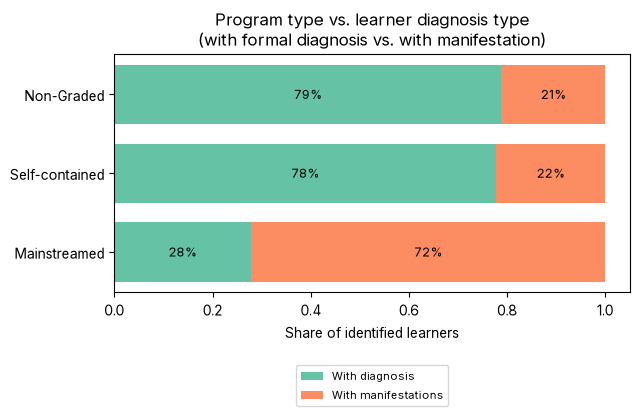

Diagnosis_Type,With Diagnosis from Licensed Medical Specialist,With Manifestations,total,pct_diagnosed,pct_manifestation
Program,,,,,
Mainstreamed,111320.0,289775.0,401095.0,0.277540,0.722460
Self-contained,14421.0,4142.0,18563.0,0.776868,0.223132
Non-Graded,75287.0,20278.0,95565.0,0.787809,0.212191


In [54]:
# Is Program associated with diagnosis vs. manifestation status?
program_only = program_diagnosis_long[program_diagnosis_long.Program != "N/A"]

program_diag_crosstab = program_only.pivot_table(
    index="Program", columns="Diagnosis_Type", values="n_learners", aggfunc="sum", fill_value=0
)
program_diag_crosstab["total"] = program_diag_crosstab.sum(axis=1)
program_diag_crosstab["pct_diagnosed"] = (
    program_diag_crosstab["With Diagnosis from Licensed Medical Specialist"] / program_diag_crosstab["total"]
)
program_diag_crosstab["pct_manifestation"] = (
    program_diag_crosstab["With Manifestations"] / program_diag_crosstab["total"]
)
program_diag_crosstab = program_diag_crosstab.sort_values("pct_manifestation", ascending=False)

counts = program_diag_crosstab[["With Diagnosis from Licensed Medical Specialist", "With Manifestations"]]
chi2, p_val, dof, expected = chi2_contingency(counts)

# Cramer's V: a sample-size-independent effect-size measure
n_total = counts.values.sum()
min_dim = min(counts.shape) - 1
cramers_v = np.sqrt(chi2 / (n_total * min_dim))
effect_label = "large" if cramers_v >= 0.5 else "medium" if cramers_v >= 0.3 else "small" if cramers_v >= 0.1 else "negligible"

most_manif = program_diag_crosstab.index[0]
most_diag = program_diag_crosstab.sort_values("pct_diagnosed", ascending=False).index[0]
print(f"Chi-square test of independence (Program x Diagnosis_Type): chi2={chi2:,.1f}, dof={dof}, p={p_val:.4g}")
print(f"Cramer's V = {cramers_v:.3f} ({effect_label} effect) -- program placement is associated "
      f"with diagnosis vs. manifestation status, and by conventional thresholds this is a "
      f"genuinely {effect_label} association, not just \"significant because n is huge.\"")
print(f"Most manifestation-associated program: {most_manif} ({program_diag_crosstab.loc[most_manif, 'pct_manifestation']:.1%} manifestation)")
print(f"Most diagnosis-associated program: {most_diag} ({program_diag_crosstab.loc[most_diag, 'pct_diagnosed']:.1%} diagnosed)")

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.barh(program_diag_crosstab.index.astype(str), program_diag_crosstab.pct_diagnosed,
        height=0.75, label="With diagnosis", color=PASTEL[0])
ax.barh(program_diag_crosstab.index.astype(str), program_diag_crosstab.pct_manifestation,
        left=program_diag_crosstab.pct_diagnosed, height=0.75, label="With manifestations", color=PASTEL[1])
for i, (d, m) in enumerate(zip(program_diag_crosstab.pct_diagnosed, program_diag_crosstab.pct_manifestation)):
    if d > 0.04:  # skip labeling a segment too thin for the text to fit legibly
        ax.text(d / 2, i, f"{d:.0%}", ha="center", va="center", fontsize=9)
    if m > 0.04:
        ax.text(d + m / 2, i, f"{m:.0%}", ha="center", va="center", fontsize=9)
ax.set_xlabel("Share of identified learners")
ax.set_title("Program type vs. learner diagnosis type\n(with formal diagnosis vs. with manifestation)")
ax.legend(loc="lower center", fontsize=8, bbox_to_anchor=(0.5, -0.5))
plt.tight_layout()
# plt.savefig(_ROOT / "figures" / "program_vs_diagnosis_type.png", dpi=200, bbox_inches="tight")
plt.show()

program_diag_crosstab

Identified SNED learners by education level:
      School_Level  total_learners
        Elementary        400935.0
Junior High School        114288.0
Senior High School          8716.0



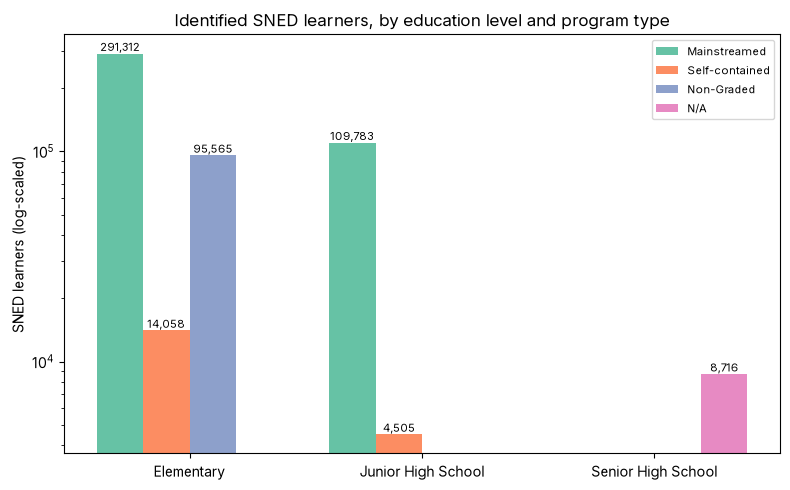

,School_Level,Program,total_learners
0,Elementary,Mainstreamed,291312.0
1,Elementary,Non-Graded,95565.0
2,Elementary,Self-contained,14058.0
3,Junior High School,Mainstreamed,109783.0
4,Junior High School,Self-contained,4505.0
5,Senior High School,N/A,8716.0


In [57]:
# Breakdown by education level: how many identified SNED learners sit in ES/JHS/SHS,
# and within ES/JHS, how that splits across Program (SHS has no Program breakdown --
# always "N/A" in the source data).
level_totals = program_diagnosis_long.groupby("School_Level", as_index=False).n_learners.sum().rename(
    columns={"n_learners": "total_learners"}
)
level_order = ["Elementary", "Junior High School", "Senior High School"]
level_totals["School_Level"] = pd.Categorical(level_totals.School_Level, categories=level_order, ordered=True)
level_totals = level_totals.sort_values("School_Level")
print("Identified SNED learners by education level:")
print(level_totals.to_string(index=False))
print()

level_program_totals = program_diagnosis_long.groupby(["School_Level", "Program"], as_index=False).n_learners.sum().rename(
    columns={"n_learners": "total_learners"}
)

program_order = ["Mainstreamed", "Self-contained", "Non-Graded", "N/A"]
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(level_order))
width = 0.2
for i, prog in enumerate(program_order):
    vals = [
        level_program_totals[(level_program_totals.School_Level == lvl) & (level_program_totals.Program == prog)]
        .total_learners.sum()
        for lvl in level_order
    ]
    bars = ax.bar(x + (i - 1.5) * width, vals, width, label=prog, color=PASTEL[i])
    for b, v in zip(bars, vals):
        if v > 0:
            ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{v:,.0f}", ha="center", va="bottom", fontsize=8, rotation=0)
ax.set_yscale("log")
ax.set_xticks(x); ax.set_xticklabels(level_order)
ax.set_ylabel("SNED learners (log-scaled)")
ax.set_title("Identified SNED learners, by education level and program type")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

level_program_totals.sort_values(["School_Level", "total_learners"], ascending=[True, False])




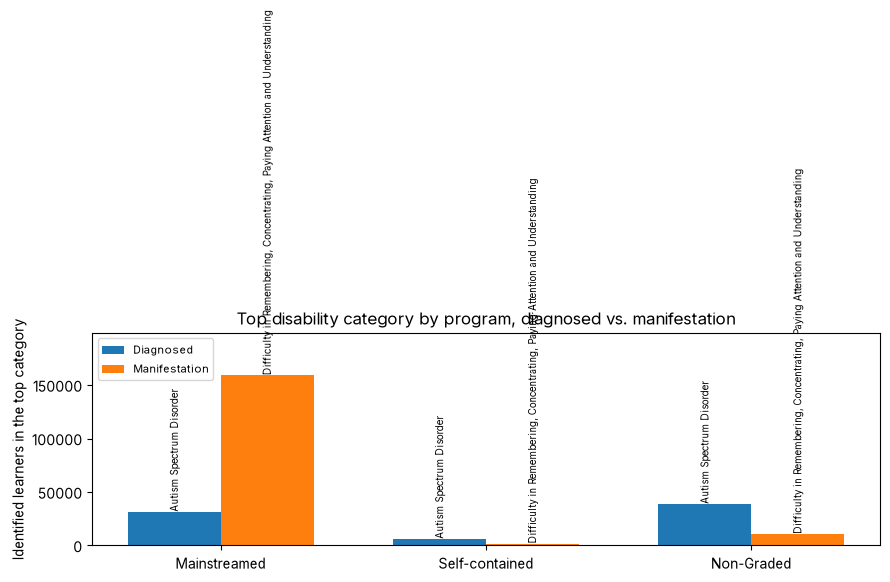

,Program,Diagnosis_Type,Category,n_learners
0,Mainstreamed,With Diagnosis from Licensed Medical Specialist,Autism Spectrum Disorder,31617.0
17,Mainstreamed,With Manifestations,"Difficulty in Remembering, Concentrating, Payi...",159036.0
19,Non-Graded,With Diagnosis from Licensed Medical Specialist,Autism Spectrum Disorder,38948.0
36,Non-Graded,With Manifestations,"Difficulty in Remembering, Concentrating, Payi...",10751.0
38,Self-contained,With Diagnosis from Licensed Medical Specialist,Autism Spectrum Disorder,6298.0
55,Self-contained,With Manifestations,"Difficulty in Remembering, Concentrating, Payi...",1731.0


In [55]:
# Top disability category per program, separately for diagnosed and manifestation-only learners.
top_by_program = (
    program_only.groupby(["Program", "Diagnosis_Type", "Category"], as_index=False).n_learners.sum()
    .sort_values("n_learners", ascending=False)
    .drop_duplicates(subset=["Program", "Diagnosis_Type"], keep="first")
    .sort_values(["Program", "Diagnosis_Type"])
)

programs = [p for p in ["Mainstreamed", "Self-contained", "Non-Graded"] if p in top_by_program.Program.unique()]
diag_rows = [top_by_program[(top_by_program.Program == p) & (top_by_program.Diagnosis_Type == "With Diagnosis from Licensed Medical Specialist")] for p in programs]
manif_rows = [top_by_program[(top_by_program.Program == p) & (top_by_program.Diagnosis_Type == "With Manifestations")] for p in programs]
diag_vals = [r.n_learners.sum() for r in diag_rows]
manif_vals = [r.n_learners.sum() for r in manif_rows]

x = np.arange(len(programs))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5.5))
b1 = ax.bar(x - width / 2, diag_vals, width, label="Diagnosed")
b2 = ax.bar(x + width / 2, manif_vals, width, label="Manifestation")
for bar, r in zip(b1, diag_rows):
    cat = r.Category.values[0] if len(r) else ""
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), cat, ha="center", va="bottom", fontsize=7, rotation=90)
for bar, r in zip(b2, manif_rows):
    cat = r.Category.values[0] if len(r) else ""
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), cat, ha="center", va="bottom", fontsize=7, rotation=90)
ax.set_xticks(x); ax.set_xticklabels(programs)
ax.set_ylabel("Identified learners in the top category")
ax.set_title("Top disability category by program, diagnosed vs. manifestation")
ax.legend(fontsize=8)
ax.margins(y=0.25)
plt.tight_layout()
# plt.savefig(_ROOT / "figures" / "top_category_by_program.png", dpi=200, bbox_inches="tight")
plt.show()

top_by_program




In [57]:
# Facility burden: learners per facility, by region/province
matched_learners = learners_with_region.loc[learners_with_region.psgc_region_name.notna(), "total_learners"].sum()
print(f"Learners successfully assigned a region via pp_summary: {matched_learners:,.0f} of "
      f"{total_learners_nationally:,.0f} national total ({matched_learners/total_learners_nationally:.1%} coverage)")

region_learners = add_region_short(
    learners_with_region.groupby("psgc_region_name", as_index=False).total_learners.sum(), "psgc_region_name"
)
region_burden = region_agg.reset_index().merge(region_learners[["region_short", "total_learners"]], on="region_short", how="left")
region_burden["learners_per_facility"] = region_burden.total_learners / region_burden.total_facilities
region_burden.sort_values("learners_per_facility", ascending=False)[["region_short", "total_facilities", "total_learners", "learners_per_facility"]]

Learners successfully assigned a region via pp_summary: 505,508 of 523,939 national total (96.5% coverage)


,region_short,total_facilities,total_learners,learners_per_facility
1,Cagayan Valley,74,31426.0,424.675676
15,SOCCSKSARGEN,67,23929.0,357.149254
8,Western Visayas,92,32415.0,352.336957
4,NCR,150,42874.0,285.826667
0,Ilocos Region,113,32200.0,284.955752
7,Bicol Region,131,36176.0,276.152672
17,BARMM,25,6844.0,273.760000
2,CAR,60,13333.0,222.216667
14,Davao Region,269,58402.0,217.107807
5,CALABARZON,285,55900.0,196.140351


In [59]:
province_learners = learners_with_region.groupby("psgc_province_name", as_index=False).total_learners.sum()
province_burden = province_agg.merge(province_learners, on="psgc_province_name", how="left")
province_burden["learners_per_facility"] = province_burden.total_learners / province_burden.total_facilities
province_burden.sort_values("learners_per_facility", ascending=False).head(3)

,psgc_region_name,psgc_province_name,n_ilrc,n_sned,n_sped_center,total_facilities,total_facilities_share,total_learners,learners_per_facility
107,Bangsamoro Autonomous Region In Muslim Mindana...,Maguindanao del Sur,0,1,1,2,0.08,3279.0,1639.5
112,Region VI (Western Visayas),City of Iloilo,0,2,0,2,0.08,2974.0,1487.0
115,Region VII (Central Visayas),City of Lapu-Lapu,0,1,0,1,0.04,1454.0,1454.0


In [60]:
national_facilities = len(roster)
national_learners_per_facility = total_learners_nationally / national_facilities
print(f"National: {total_learners_nationally:,.0f} learners / {national_facilities:,} facilities "
      f"= {national_learners_per_facility:.1f} learners per facility")

National: 523,939 learners / 2,629 facilities = 199.3 learners per facility


In [61]:
region_burden["facilities_per_1000_learners"] = region_burden.total_facilities / region_burden.total_learners * 1000
region_burden["learners_per_facility"] = region_burden.total_learners / region_burden.total_facilities
national_facilities_per_1000 = national_facilities / total_learners_nationally * 1000

print(f"National: {national_facilities_per_1000:.2f} facilities per 1,000 identified SNED learners")
region_burden.sort_values("facilities_per_1000_learners").head(3)

National: 5.02 facilities per 1,000 identified SNED learners


,region_short,n_ilrc,n_sned,n_sped_center,total_facilities,total_facilities_share,total_learners,learners_per_facility,facilities_per_1000_learners
1,Cagayan Valley,3,67,23,74,2.82,31426.0,424.675676,2.354738
15,SOCCSKSARGEN,4,60,17,67,2.55,23929.0,357.149254,2.799950
8,Western Visayas,4,76,22,92,3.50,32415.0,352.336957,2.838192


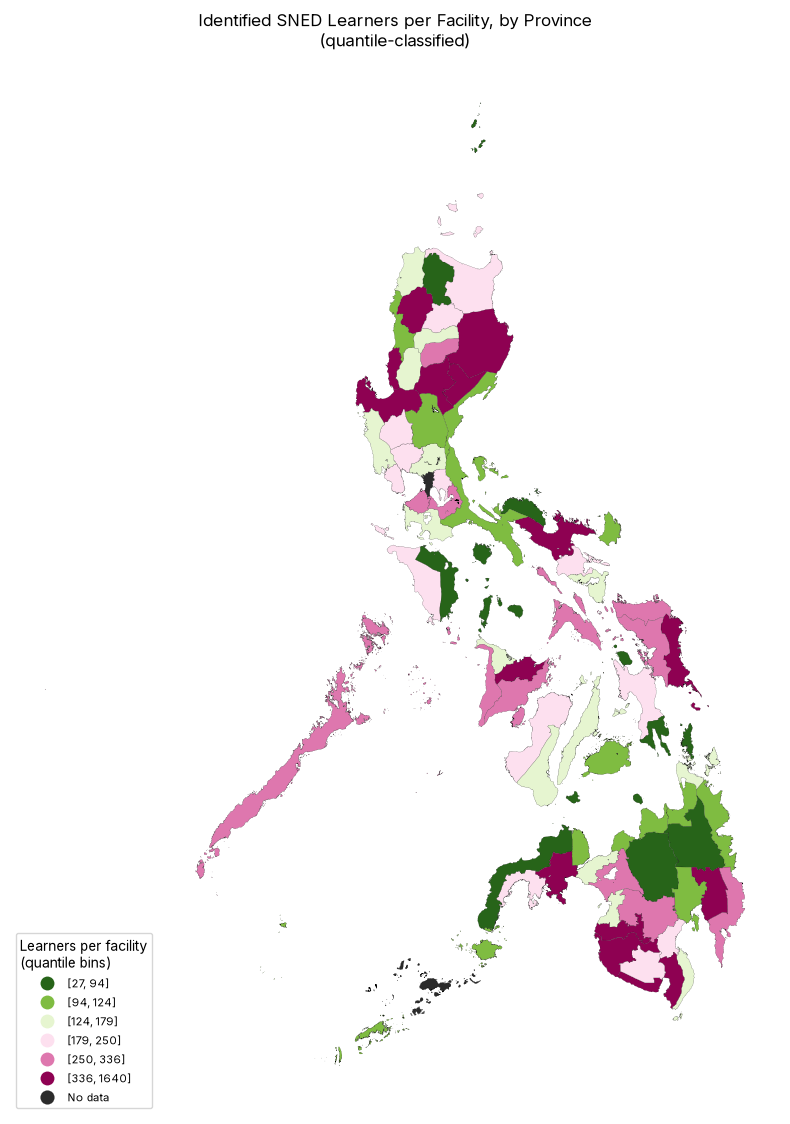

,psgc_province_name,total_facilities,total_learners,learners_per_facility
107,Maguindanao del Sur,2,3279.0,1639.500000
112,City of Iloilo,2,2974.0,1487.000000
115,City of Lapu-Lapu,1,1454.0,1454.000000
109,City of Baguio,2,2660.0,1330.000000
113,Abra,1,1270.0,1270.000000
101,City of Caloocan,3,3089.0,1029.666667
97,City of Mandaluyong,4,3522.0,880.500000
110,City of Puerto Princesa,2,1760.0,880.000000
100,City of Olongapo,4,3032.0,758.000000
38,Isabela,21,15106.0,719.333333


In [62]:
# Province choropleth
province_shapes = brgy.dissolve(by="adm2_en").reset_index()

province_choropleth_df = province_shapes.merge(
    province_burden[["psgc_province_name", "learners_per_facility"]],
    left_on="adm2_en", right_on="psgc_province_name", how="left"
)
province_choropleth_df["learners_per_facility"] = province_choropleth_df["learners_per_facility"].replace([np.inf, -np.inf], np.nan)

import mapclassify
classifier = mapclassify.Quantiles(province_choropleth_df["learners_per_facility"].dropna(), k=6)
bin_edges = [province_choropleth_df["learners_per_facility"].min()] + list(classifier.bins)

fig, ax = plt.subplots(figsize=(8, 12))
province_choropleth_df.plot(
    column="learners_per_facility", scheme="Quantiles", k=6, cmap=SCALE_CMAP,
    legend=True, edgecolor="black", linewidth=0.1, ax=ax,
    missing_kwds={"color": "#2B2B2B", "label": "No data"},
    legend_kwds={"loc": "lower left", "title": "Learners per facility\n(quantile bins)", "fontsize": 8},
)

legend = ax.get_legend()
n_bins = len(bin_edges) - 1
for i, text in enumerate(legend.get_texts()):
    if i >= n_bins:
        continue
    lo, hi = np.round(bin_edges[i], 0), np.round(bin_edges[i + 1], 0)
    text.set_text(f"[{lo:.0f}, {hi:.0f}]")

ax.set_title("Identified SNED Learners per Facility, by Province\n(quantile-classified)")
ax.set_axis_off()
plt.tight_layout()
plt.show()

province_burden.sort_values("learners_per_facility", ascending=False).head(10)[
    ["psgc_province_name", "total_facilities", "total_learners", "learners_per_facility"]
]

In [64]:
province_choropleth_df["learners_per_facility"].median().round(2)

np.float64(179.27)

Facilities plotted: 2,608 of 2,629 (21 excluded -- unroutable coordinates, see roster.coord_status)


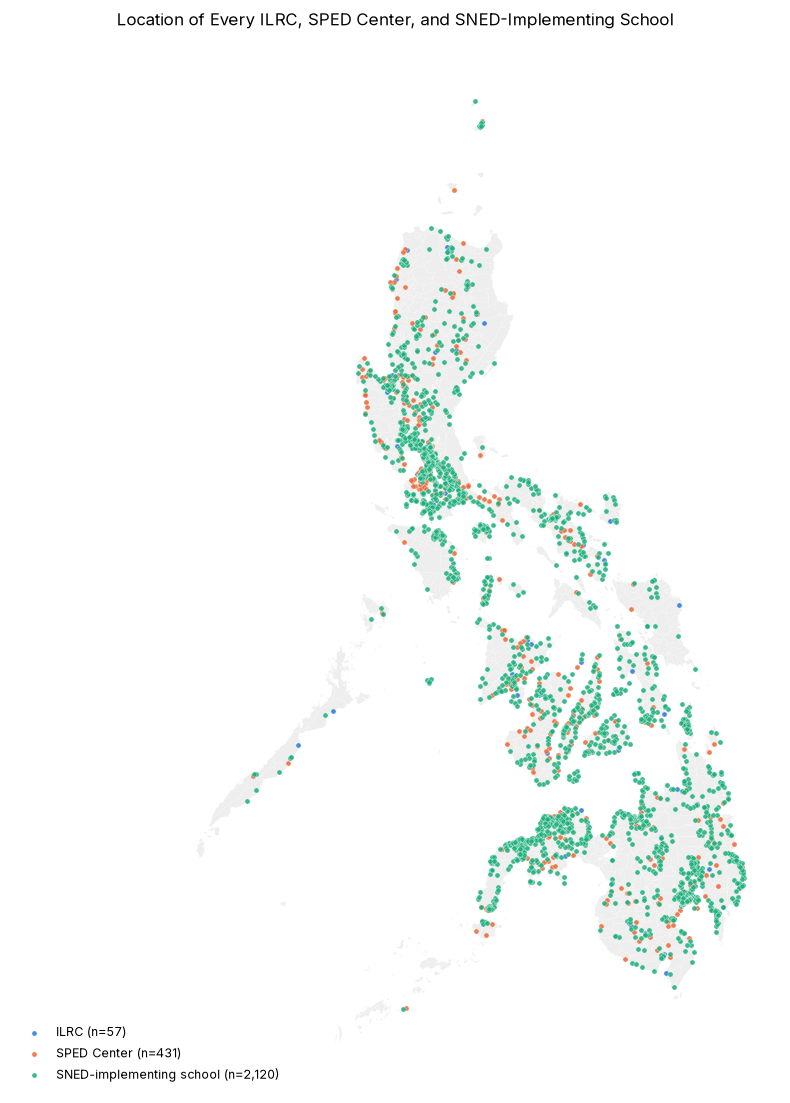

In [65]:
# National facility map
facility_type_priority = ["ILRC", "SPED Center", "SNED-implementing school"]

map_facilities = roster[roster["coord_status"] == "valid"].copy()
n_excluded_coords = len(roster) - len(map_facilities)
print(f"Facilities plotted: {len(map_facilities):,} of {len(roster):,} "
      f"({n_excluded_coords} excluded -- unroutable coordinates, see roster.coord_status)")

map_facilities["facility_type"] = np.select(
    [map_facilities.is_ilrc, map_facilities.is_sped_center, map_facilities.is_sned],
    ["ILRC", "SPED Center", "SNED-implementing school"],
    default=None,
)
map_facilities["facility_type"] = pd.Categorical(map_facilities["facility_type"], categories=facility_type_priority)

facility_type_colors = {
    "ILRC": "#2a78d6",
    "SPED Center": "#eb6834",
    "SNED-implementing school": "#1baf7a",
}

fig, ax = plt.subplots(figsize=(8, 12))
muni_shapes.plot(ax=ax, color="#EEEEEE", edgecolor="white", linewidth=0.1)

for facility_type in facility_type_priority:
    subset = map_facilities[map_facilities["facility_type"] == facility_type]
    ax.scatter(
        subset["longitude"], subset["latitude"],
        s=14, c=facility_type_colors[facility_type], label=f"{facility_type} (n={len(subset):,})",
        edgecolor="white", linewidth=0.3, alpha=0.85, zorder=3,
    )

ax.set_title("Location of Every ILRC, SPED Center, and SNED-Implementing School")
ax.set_axis_off()
ax.legend(loc="lower left", frameon=False, fontsize=9)
plt.tight_layout()
# plt.savefig(_ROOT / "figures" / "national_facility_map.png", dpi=200, bbox_inches="tight")
plt.show()


### **G. Additionals 2**

Self-contained learners as % of each region's Mainstreamed+Self-contained+Non-Graded population:


Program,Mainstreamed,Self-contained,Non-Graded,total,pct_self_contained
region_label,,,,,
Northern Mindanao,7994.0,1459.0,4647.0,14100.0,10.35
NCR,25237.0,3474.0,16786.0,45497.0,7.64
Central Luzon,21225.0,2505.0,11440.0,35170.0,7.12
Central Visayas,22478.0,1800.0,4611.0,28889.0,6.23
CALABARZON,37690.0,2222.0,16764.0,56676.0,3.92
Eastern Visayas,10753.0,517.0,2600.0,13870.0,3.73
Bicol Region,30723.0,1324.0,4235.0,36282.0,3.65
Zamboanga Peninsula,29015.0,1055.0,4452.0,34522.0,3.06
SOCCSKSARGEN,21021.0,726.0,2545.0,24292.0,2.99



Regions reporting ZERO Self-contained learners despite having Mainstreamed/Non-Graded learners: []
(Consistent with -- though not proof of -- a region-level policy no longer permitting the option; cross-check against DepEd regional office guidance before treating this as confirmed.)

Chi-square test of independence (Region x Program): chi2=45,555.8, dof=34, p=0
Cramer's V = 0.210 (small effect) -- program placement IS associated with region, a genuinely small association by conventional thresholds.


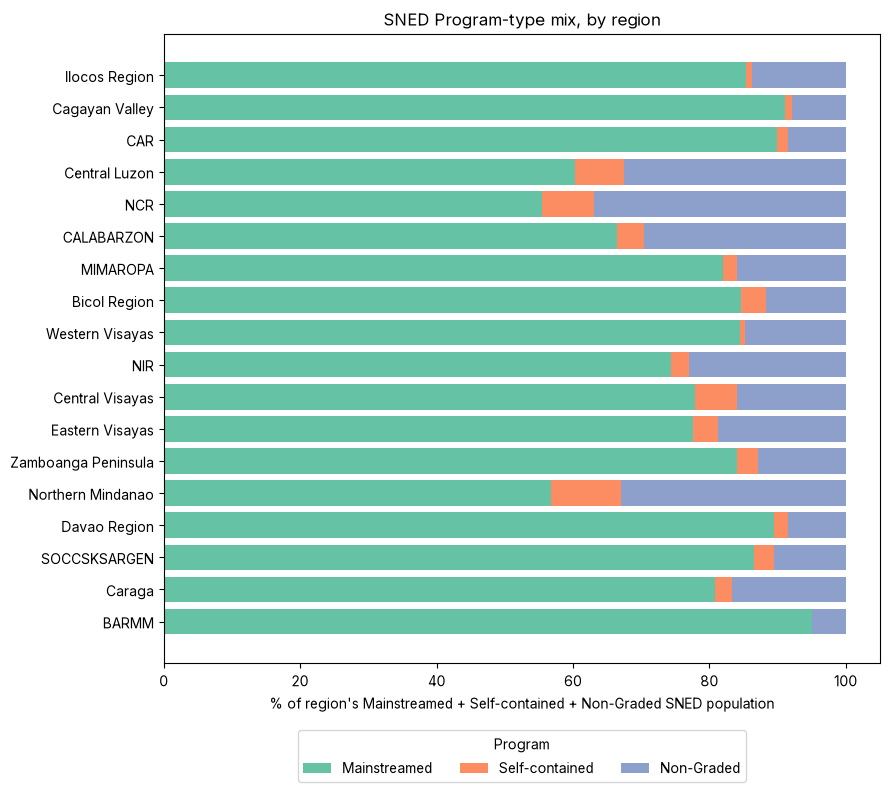

In [66]:
# Is "Self-contained" placement concentrated in specific regions?
def _normalize_region_label(s):
    return s.astype(str).str.strip().str.replace(r'^Region\s+', '', regex=True)

REGION_CODE_LABELS_LOCAL = {
    'I': 'Ilocos Region', 
    'II': 'Cagayan Valley', 
    'III': 'Central Luzon', 
    'IV-A': 'CALABARZON',
    'MIMAROPA': 'MIMAROPA', 
    'V': 'Bicol Region', 
    'VI': 'Western Visayas', 
    'VII': 'Central Visayas',
    'VIII': 'Eastern Visayas', 
    'IX': 'Zamboanga Peninsula', 
    'X': 'Northern Mindanao', 
    'XI': 'Davao Region',
    'XII': 'SOCCSKSARGEN',
    'CARAGA': 'Caraga',
    'CAR': 'CAR', 
    'NCR': 'NCR', 
    'NIR': 'NIR', 
    'BARMM': 'BARMM',
}
REGION_DISPLAY_ORDER = ['Ilocos Region', 'Cagayan Valley', 'CAR', 'Central Luzon', 'NCR', 'CALABARZON', 'MIMAROPA',
                        'Bicol Region', 'Western Visayas', 'NIR', 'Central Visayas', 'Eastern Visayas', 'Zamboanga Peninsula',
                        'Northern Mindanao', 'Davao Region', 'SOCCSKSARGEN', 'Caraga', 'BARMM']

region_program_raw = con.execute(f"""
    SELECT Region AS region_raw, Program, SUM(Learner_Count) AS n_learners
    FROM read_parquet('{PARQUET_PATH.as_posix()}')
    WHERE Learner_Count > 0 AND Program IN ('Mainstreamed', 'Self-contained', 'Non-Graded')
    GROUP BY Region, Program
""").df()
region_program_raw['region_code'] = _normalize_region_label(region_program_raw['region_raw'])
region_program_raw['region_label'] = region_program_raw['region_code'].map(REGION_CODE_LABELS_LOCAL)

unmapped_regions = set(region_program_raw.loc[region_program_raw['region_label'].isna(), 'region_raw'])
if unmapped_regions:
    print(f"WARNING -- region strings with no label mapping (check spelling/format): {unmapped_regions}")

region_program_pivot = (
    region_program_raw.pivot_table(index='region_label', columns='Program', values='n_learners',
                                    aggfunc='sum', fill_value=0)
    .reindex(REGION_DISPLAY_ORDER)
)
region_program_pivot['total'] = region_program_pivot.sum(axis=1)
region_program_pivot['pct_self_contained'] = (
    region_program_pivot.get('Self-contained', 0) / region_program_pivot['total'] * 100
).round(2)

print("Self-contained learners as % of each region's Mainstreamed+Self-contained+Non-Graded population:")
display(region_program_pivot[['Mainstreamed', 'Self-contained', 'Non-Graded', 'total', 'pct_self_contained']]
        .sort_values('pct_self_contained', ascending=False))

zero_sc = region_program_pivot[region_program_pivot['Self-contained'] <= 0]
print(f"\nRegions reporting ZERO Self-contained learners despite having Mainstreamed/Non-Graded learners: "
      f"{list(zero_sc.index)}")
print("(Consistent with -- though not proof of -- a region-level policy no longer permitting the option; "
      "cross-check against DepEd regional office guidance before treating this as confirmed.)")

region_program_crosstab = region_program_pivot[['Mainstreamed', 'Self-contained', 'Non-Graded']]
chi2, p_val, dof, expected = chi2_contingency(region_program_crosstab)
n_total = region_program_crosstab.values.sum()
min_dim = min(region_program_crosstab.shape) - 1
cramers_v = np.sqrt(chi2 / (n_total * min_dim))
effect_label = "large" if cramers_v >= 0.5 else "medium" if cramers_v >= 0.3 else "small" if cramers_v >= 0.1 else "negligible"
print(f"\nChi-square test of independence (Region x Program): chi2={chi2:,.1f}, dof={dof}, p={p_val:.4g}")
print(f"Cramer's V = {cramers_v:.3f} ({effect_label} effect) -- program placement IS associated with "
      f"region, a genuinely {effect_label} association by conventional thresholds.")

fig, ax = plt.subplots(figsize=(9, 8))
pct_mix = region_program_crosstab.div(region_program_crosstab.sum(axis=1), axis=0) * 100
bottom = np.zeros(len(pct_mix))
for i, prog in enumerate(['Mainstreamed', 'Self-contained', 'Non-Graded']):
    ax.barh(pct_mix.index.astype(str), pct_mix[prog], left=bottom, label=prog, color=PASTEL[i])
    bottom += pct_mix[prog].values
ax.set_xlabel("% of region's Mainstreamed + Self-contained + Non-Graded SNED population")
ax.set_title("SNED Program-type mix, by region")
ax.legend(title="Program", bbox_to_anchor=(0.5, -0.2), ncol=3, loc="lower center")
ax.invert_yaxis()
plt.tight_layout()
# plt.savefig(_ROOT / "figures" / "region_self_contained_share.png", dpi=200, bbox_inches="tight")
plt.show()

In [67]:
display(region_program_pivot[['Mainstreamed', 'Self-contained', 'Non-Graded', 'total', 'pct_self_contained']]
        .sort_values('Self-contained', ascending=False))

Program,Mainstreamed,Self-contained,Non-Graded,total,pct_self_contained
region_label,,,,,
NCR,25237.0,3474.0,16786.0,45497.0,7.64
Central Luzon,21225.0,2505.0,11440.0,35170.0,7.12
CALABARZON,37690.0,2222.0,16764.0,56676.0,3.92
Central Visayas,22478.0,1800.0,4611.0,28889.0,6.23
Northern Mindanao,7994.0,1459.0,4647.0,14100.0,10.35
Bicol Region,30723.0,1324.0,4235.0,36282.0,3.65
Davao Region,53226.0,1195.0,5035.0,59456.0,2.01
Zamboanga Peninsula,29015.0,1055.0,4452.0,34522.0,3.06
SOCCSKSARGEN,21021.0,726.0,2545.0,24292.0,2.99


In [68]:
# SNED-desert municipalities that ALSO carry a heavy identified-LWD burden. 
TOP_N_DESERT = 30  # adjust freely between 20 and 30 per the request

def desert_lwd_burden(lgu_df, muni_share_df, label, top_n=TOP_N_DESERT):
    flag_cols = lgu_df[["psgc_municity", "lgu_has_no_facility_at_all", "coverage_class"]]
    out = muni_share_df.merge(flag_cols, on="psgc_municity", how="left")
    out = out[out["lgu_has_no_facility_at_all"] == True].copy()
    out = add_region_short(out)
    out["pct_unserved"] = (out["pct_unserved"] * 100).round(1)
    out["share_of_national_unserved"] = (
        out["unserved_total"] / muni_share_df["unserved_total"].sum() * 100
    ).round(2)

    n_zero_coverage = (out["coverage_class"] == "Zero coverage").sum()
    print(f"--- {label}: SNED-desert municipalities (no facility inside the municipal boundary) ---")
    print(f"{len(out):,} municipalities qualify as deserts.")
    print(f"  Of these, {n_zero_coverage:,} have ZERO coverage (no neighbor rescue either -- "
          f"100% of their own identified learners are unserved).")
    print(f"  The remaining {len(out) - n_zero_coverage:,} are 'desert but partially/fully covered' "
          f"via a neighboring municipality's facility (see 3.5).")
    return out.sort_values("total_learners_muni", ascending=False).head(top_n)

DISPLAY_COLS = ["psgc_municity_name", "psgc_province_name", "region_short",
                "total_learners_muni", "unserved_total", "unserved_diagnosed", "unserved_manif",
                "pct_unserved", "share_of_national_unserved", "coverage_class"]

desert_burden_pp = desert_lwd_burden(lgu_pp, muni_share_pp, "Public+private population")
print(f"\nTop {TOP_N_DESERT} SNED-desert municipalities, ranked by total identified LWD count:")
display(desert_burden_pp[DISPLAY_COLS])

desert_burden_pub = desert_lwd_burden(lgu_pub, muni_share_pub, "Public-only population")
print(f"\n[Public-only sensitivity check] Top {TOP_N_DESERT}:")
display(desert_burden_pub[DISPLAY_COLS])

# --- Same population, re-ranked by PROPORTION rather than absolute count (reading (a) above) ---
desert_all_pp = muni_share_pp.merge(
    lgu_pp[["psgc_municity", "lgu_has_no_facility_at_all", "coverage_class"]], on="psgc_municity", how="left"
)
desert_all_pp = desert_all_pp[desert_all_pp["lgu_has_no_facility_at_all"] == True]
desert_all_pp = add_region_short(desert_all_pp)
desert_by_pct = desert_all_pp[desert_all_pp["total_learners_muni"] >= MIN_LEARNERS].copy()  # MIN_LEARNERS from 3.4
desert_by_pct["pct_unserved"] = (desert_by_pct["pct_unserved"] * 100).round(1)
print(f"\nSame desert municipalities, re-ranked by SHARE of their own LWD population left unserved "
      f"(min. {MIN_LEARNERS} identified learners, matching 3.4's noise floor):")
display(desert_by_pct.sort_values("unserved_total", ascending=False).head(TOP_N_DESERT)
        [["psgc_municity_name", "psgc_province_name", "total_learners_muni",]])

--- Public+private population: SNED-desert municipalities (no facility inside the municipal boundary) ---
543 municipalities qualify as deserts.
  Of these, 472 have ZERO coverage (no neighbor rescue either -- 100% of their own identified learners are unserved).
  The remaining 71 are 'desert but partially/fully covered' via a neighboring municipality's facility (see 3.5).

Top 30 SNED-desert municipalities, ranked by total identified LWD count:


,psgc_municity_name,psgc_province_name,region_short,total_learners_muni,unserved_total,unserved_diagnosed,unserved_manif,pct_unserved,share_of_national_unserved,coverage_class
988,Molave,Zamboanga del Sur,Zamboanga Peninsula,1066.0,1011.0,84.0,927.0,94.8,0.47,Partial coverage
163,Benito Soliven,Isabela,Cagayan Valley,1017.0,1017.0,59.0,958.0,100.0,0.47,Zero coverage
541,Minalabac,Camarines Sur,Bicol Region,948.0,948.0,110.0,838.0,100.0,0.44,Zero coverage
120,Umingan,Pangasinan,Ilocos Region,894.0,894.0,205.0,689.0,100.0,0.41,Zero coverage
1428,Bataraza,Palawan,MIMAROPA,803.0,803.0,162.0,641.0,100.0,0.37,Zero coverage
1198,Lutayan,Sultan Kudarat,SOCCSKSARGEN,723.0,723.0,53.0,670.0,100.0,0.33,Zero coverage
1624,South Upi,Maguindanao del Sur,BARMM,713.0,713.0,84.0,629.0,100.0,0.33,Zero coverage
550,Sagñay,Camarines Sur,Bicol Region,710.0,638.0,140.0,498.0,89.9,0.29,Partial coverage
178,Mallig,Isabela,Cagayan Valley,702.0,702.0,44.0,658.0,100.0,0.32,Zero coverage
101,Manaoag,Pangasinan,Ilocos Region,663.0,626.0,176.0,450.0,94.4,0.29,Partial coverage


--- Public-only population: SNED-desert municipalities (no facility inside the municipal boundary) ---
542 municipalities qualify as deserts.
  Of these, 473 have ZERO coverage (no neighbor rescue either -- 100% of their own identified learners are unserved).
  The remaining 69 are 'desert but partially/fully covered' via a neighboring municipality's facility (see 3.5).

[Public-only sensitivity check] Top 30:


,psgc_municity_name,psgc_province_name,region_short,total_learners_muni,unserved_total,unserved_diagnosed,unserved_manif,pct_unserved,share_of_national_unserved,coverage_class
988,Molave,Zamboanga del Sur,Zamboanga Peninsula,1020.0,965.0,77.0,888.0,94.6,0.45,Partial coverage
163,Benito Soliven,Isabela,Cagayan Valley,1017.0,1017.0,59.0,958.0,100.0,0.48,Zero coverage
541,Minalabac,Camarines Sur,Bicol Region,942.0,942.0,110.0,832.0,100.0,0.44,Zero coverage
120,Umingan,Pangasinan,Ilocos Region,894.0,894.0,205.0,689.0,100.0,0.42,Zero coverage
1427,Bataraza,Palawan,MIMAROPA,803.0,803.0,162.0,641.0,100.0,0.38,Zero coverage
1198,Lutayan,Sultan Kudarat,SOCCSKSARGEN,723.0,723.0,53.0,670.0,100.0,0.34,Zero coverage
1623,South Upi,Maguindanao del Sur,BARMM,713.0,713.0,84.0,629.0,100.0,0.34,Zero coverage
550,Sagñay,Camarines Sur,Bicol Region,710.0,638.0,140.0,498.0,89.9,0.30,Partial coverage
178,Mallig,Isabela,Cagayan Valley,700.0,700.0,43.0,657.0,100.0,0.33,Zero coverage
101,Manaoag,Pangasinan,Ilocos Region,647.0,610.0,168.0,442.0,94.3,0.29,Partial coverage



Same desert municipalities, re-ranked by SHARE of their own LWD population left unserved (min. 30 identified learners, matching 3.4's noise floor):


,psgc_municity_name,psgc_province_name,total_learners_muni
163,Benito Soliven,Isabela,1017.0
988,Molave,Zamboanga del Sur,1066.0
541,Minalabac,Camarines Sur,948.0
120,Umingan,Pangasinan,894.0
1428,Bataraza,Palawan,803.0
1198,Lutayan,Sultan Kudarat,723.0
1624,South Upi,Maguindanao del Sur,713.0
178,Mallig,Isabela,702.0
1167,Libungan,Cotabato,644.0
550,Sagñay,Camarines Sur,710.0


Top-line: does the school hold ANY of the three facility roles (ILRC / SPED Center / SNED-implementing)?


,Not any facility type,ILRC / SPED Center / SNED school (any),total,pct_in_any_facility
Program,,,,
Mainstreamed,336745.0,64350.0,401095.0,16.0
Self-contained,8090.0,10473.0,18563.0,56.4
Non-Graded,17421.0,78144.0,95565.0,81.8



Granular breakdown -- learners by Program, by specific facility type of the school they attend (mutually exclusive: a multi-role facility counts once, toward its highest-priority role, ILRC > SPED Center > SNED school):


facility_type_dedup,ILRC,SPED Center,SNED school,Not a facility
Program,,,,
Mainstreamed,3301.0,14360.0,46689.0,336745.0
Self-contained,1598.0,3790.0,5085.0,8090.0
Non-Graded,5992.0,24914.0,47238.0,17421.0



Same table, as row percentages:


facility_type_dedup,ILRC,SPED Center,SNED school,Not a facility
Program,,,,
Mainstreamed,0.8,3.6,11.6,84.0
Self-contained,8.6,20.4,27.4,43.6
Non-Graded,6.3,26.1,49.4,18.2



Distinct schools reporting >=1 Non-Graded learner, by facility type: {'ILRC': 56, 'SPED Center': 417, 'SNED school': 1802, 'Not a facility': 1600}


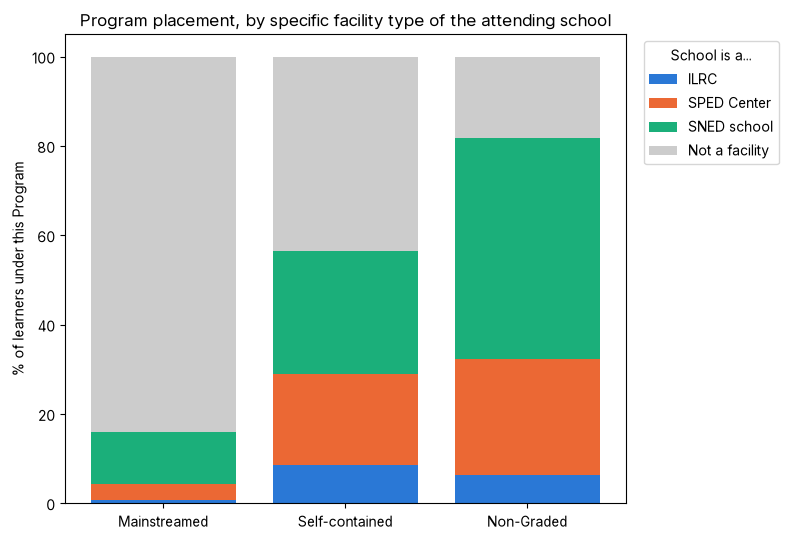

In [70]:
school_program_totals = con.execute(f"""
    SELECT beis_school_id, Program, SUM(Learner_Count) AS n_learners
    FROM read_parquet('{PARQUET_PATH.as_posix()}')
    WHERE Learner_Count > 0
    GROUP BY beis_school_id, Program
""").df()

program_facility = school_program_totals.merge(
    roster[['school_id', 'is_ilrc', 'is_sped_center', 'is_sned', 'is_any_facility', 'facility_type_dedup']],
    left_on='beis_school_id', right_on='school_id', how='left'
)
for c in ['is_ilrc', 'is_sped_center', 'is_sned', 'is_any_facility']:
    program_facility[c] = program_facility[c].fillna(False)
program_facility['facility_type_dedup'] = program_facility['facility_type_dedup'].fillna('Not a facility')

PROGRAMS = ['Mainstreamed', 'Self-contained', 'Non-Graded']
program_facility_sub = program_facility[program_facility['Program'].isin(PROGRAMS)]

# --- (a) Top-line: does the school hold ANY of the three facility roles? ---
any_facility_summary = (
    program_facility_sub.groupby(['Program', 'is_any_facility'])['n_learners'].sum()
    .unstack(fill_value=0)
)
any_facility_summary.columns = ['Not any facility type', 'ILRC / SPED Center / SNED school (any)']
any_facility_summary['total'] = any_facility_summary.sum(axis=1)
any_facility_summary['pct_in_any_facility'] = (
    any_facility_summary['ILRC / SPED Center / SNED school (any)'] / any_facility_summary['total'] * 100
).round(1)
print("Top-line: does the school hold ANY of the three facility roles (ILRC / SPED Center / SNED-implementing)?")
display(any_facility_summary.reindex(PROGRAMS))

# --- (b) Granular: which SPECIFIC facility type (mutually exclusive via facility_type_dedup) ---
by_type = (
    program_facility_sub.groupby(['Program', 'facility_type_dedup'])['n_learners'].sum()
    .unstack(fill_value=0)
    .reindex(columns=['ILRC', 'SPED Center', 'SNED school', 'Not a facility'], fill_value=0)
)
by_type_pct = by_type.div(by_type.sum(axis=1), axis=0) * 100

print("\nGranular breakdown -- learners by Program, by specific facility type of the school they attend "
      "(mutually exclusive: a multi-role facility counts once, toward its highest-priority role, "
      "ILRC > SPED Center > SNED school):")
display(by_type.reindex(PROGRAMS))
print("\nSame table, as row percentages:")
display(by_type_pct.reindex(PROGRAMS).round(1))

n_nongraded_by_type = (
    program_facility[program_facility['Program'] == 'Non-Graded']
    .groupby('facility_type_dedup')['beis_school_id'].nunique()
    .reindex(['ILRC', 'SPED Center', 'SNED school', 'Not a facility'], fill_value=0)
)
print(f"\nDistinct schools reporting >=1 Non-Graded learner, by facility type: {n_nongraded_by_type.to_dict()}")

# Visual: stacked bar of Program x facility-type mix
fig, ax = plt.subplots(figsize=(8, 5.5))
plot_pct = by_type_pct.reindex(PROGRAMS)
bottom = np.zeros(len(plot_pct))
type_colors = {'ILRC': '#2a78d6', 'SPED Center': '#eb6834', 'SNED school': '#1baf7a', 'Not a facility': '#CCCCCC'}
for ftype in ['ILRC', 'SPED Center', 'SNED school', 'Not a facility']:
    ax.bar(plot_pct.index.astype(str), plot_pct[ftype], bottom=bottom, label=ftype, color=type_colors[ftype])
    bottom += plot_pct[ftype].values
ax.set_ylabel('% of learners under this Program')
ax.set_title('Program placement, by specific facility type of the attending school')
ax.legend(title='School is a...', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
# plt.savefig(_ROOT / "figures" / "nongraded_by_facility_type.png", dpi=200, bbox_inches="tight")
plt.show()

### **H. Exports**

In [71]:
# ==========================================================================
# EXPORT 1 — Facility profile: location, enrollment, per-category learner counts,
# top diagnosed/manifestation category. 
# ==========================================================================
EXPORT_DIR = DATA / "exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

facility_category_wide = (
    school_disability_long[school_disability_long["beis_school_id"].isin(roster["school_id"])]
    .groupby(["beis_school_id", "Category"], as_index=False)["n_learners"].sum()
    .pivot(index="beis_school_id", columns="Category", values="n_learners")
    .fillna(0)
)
facility_category_wide.columns = [f"n_{c.lower().replace(' ', '_').replace('/', '_')}" for c in facility_category_wide.columns]
facility_category_wide = facility_category_wide.reset_index().rename(columns={"beis_school_id": "school_id"})

LOCATION_COLS = ["school_id", "school_name", "psgc_region_name", "psgc_province_name",
                  "psgc_municity_name", "is_ilrc", "is_sped_center", "is_sned"]
facility_export = (
    roster[roster["is_any_facility"]][LOCATION_COLS]
    .merge(school_totals.rename(columns={"beis_school_id": "school_id"})
           [["school_id", "n_diagnosed", "n_manifestation", "total_learners",
             "top_diagnosed_category", "top_diagnosed_n",
             "top_manifestation_category", "top_manifestation_n"]],
           on="school_id", how="left")
    .merge(facility_category_wide, on="school_id", how="left")
)
facility_export = facility_export.rename(columns={"total_learners": "enrollment_identified_sned"})
facility_export.to_csv(EXPORT_DIR / "q4_facility_profile_full.csv", index=False)
print(f"Saved {len(facility_export):,} rows -> {EXPORT_DIR / 'q4_facility_profile_full.csv'}")

# ==========================================================================
# EXPORT 2 — Full SNED-desert municipality list (public+private population),
# with learner burden and the "desert but covered" nuance.
# ==========================================================================
desert_export = muni_share_pp.merge(
    lgu_pp[["psgc_municity", "lgu_has_no_facility_at_all", "coverage_class"]], on="psgc_municity", how="left"
)
desert_export = desert_export[desert_export["lgu_has_no_facility_at_all"] == True].copy()
desert_export = add_region_short(desert_export)
desert_export["pct_unserved"] = (desert_export["pct_unserved"] * 100).round(1)
desert_export["share_of_national_unserved"] = (
    desert_export["unserved_total"] / muni_share_pp["unserved_total"].sum() * 100
).round(2)
desert_export = desert_export.sort_values("total_learners_muni", ascending=False)[DISPLAY_COLS]
desert_export.to_csv(EXPORT_DIR / "q4_sned_desert_municipalities.csv", index=False)
print(f"Saved {len(desert_export):,} rows -> {EXPORT_DIR / 'q4_sned_desert_municipalities.csv'}")

# ==========================================================================
# EXPORT 3 — Host schools and their satellites within 3km (public+private
# population pairs table, pp_pairs), with a clear host-row flag.
# ==========================================================================
pairs_export = pp_pairs.copy()
pairs_export["is_host_row"] = pairs_export["facility_school_id"] == pairs_export["population_school_id"]
pairs_export = pairs_export.rename(columns={
    "population_school_id": "satellite_school_id", "population_school_name": "satellite_school_name",
    "population_psgc_municity": "satellite_psgc_municity", "population_psgc_municity_name": "satellite_psgc_municity_name",
})
pairs_export.to_csv(EXPORT_DIR / "q4_host_satellite_pairs_3km.csv", index=False)
print(f"Saved {len(pairs_export):,} rows -> {EXPORT_DIR / 'q4_host_satellite_pairs_3km.csv'}")

Saved 2,629 rows -> c:\Users\Lanz Railey Fermin\Desktop\ecair_work\sned-analysis\data\exports\q4_facility_profile_full.csv
Saved 543 rows -> c:\Users\Lanz Railey Fermin\Desktop\ecair_work\sned-analysis\data\exports\q4_sned_desert_municipalities.csv
Saved 28,438 rows -> c:\Users\Lanz Railey Fermin\Desktop\ecair_work\sned-analysis\data\exports\q4_host_satellite_pairs_3km.csv
